In [1]:
import os
import numpy as np
import pandas as pd
from obspy import read
from obspy.core.trace import Trace
import matplotlib.pyplot as plt

In [49]:
# ============================================================
# Event selection only (no plotting, no saving)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print: per scenario list of selected events (time, station, epicentral distance)
# ============================================================

import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=4, K_NEG=0, K_PRE_POS=0),
]

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)
t0_mat = (
    df_long.pivot_table(
        index="event",
        columns="band",
        values="t0_dt_mean_dt",
        aggfunc="first"
    )
    .reindex(columns=BANDS)
    .sort_index()
)

print(t0_mat.head())
# event-level distance
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(f" No events after MiniSEED matching.")
        continue

    # Build and print table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,  # <-- add this back
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print all selected events (or use .head(20) if too long)
    print(f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS} \n Selected events (time_utc, station, epi_deg):")
    print(out_df.to_string(index=False))


band                                                               3.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.803000+00:00   
1971-05-20 17:16:10.013000+00:00__S14 1971-05-20 17:28:58.621000+00:00   
1972-01-02 22:20:40.002000+00:00__S15                              NaT   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:40.242000+00:00   
1972-12-06 22:59:00.008000+00:00__S14 1972-12-06 23:12:35.496000+00:00   

band                                                               4.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.620000+00:00   
1971-05-20 17:16:10.013000+00:00__S14                              NaT   
1972-01-02 22:20:40.002000+00:00__S15 1972-01-02 22:33:18.748000+00:00   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:45.132000+00:00   
1972-12-06 22:59:00.008000+00:00__S14

In [3]:
def select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    *,
    target_deg,
    tol_deg=0.01,
    mode="closest",
    event_col="event",
    dist_col=None
):
    d = out_df.copy()

    if dist_col is None:
        if "epi_deg" in d.columns:
            dist_col = "epi_deg"
        elif "distance_deg" in d.columns:
            dist_col = "distance_deg"
        else:
            raise KeyError("out_df must contain 'epi_deg' or 'distance_deg'")

    d[dist_col] = pd.to_numeric(d[dist_col], errors="coerce")
    d = d[d[dist_col].notna()]
    if d.empty:
        return None, None, None

    win = d[(d[dist_col] >= target_deg - tol_deg) & (d[dist_col] <= target_deg + tol_deg)]
    if win.empty:
        return None, None, None

    if mode == "closest":
        idx = (win[dist_col] - target_deg).abs().idxmin()
    elif mode == "min":
        idx = win[dist_col].idxmin()
    elif mode == "max":
        idx = win[dist_col].idxmax()
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if event_col not in win.columns:
        raise KeyError(f"out_df must contain '{event_col}' to map to event_to_trace")

    chosen_row = win.loc[idx]
    chosen_event = chosen_row[event_col]
    tr = event_to_trace.get(chosen_event)

    return tr, chosen_event, chosen_row


In [4]:
from scipy.optimize import curve_fit
from obspy import UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window

# ---------------------------
# Signal processing helpers
# ---------------------------
def band_edges(fc, half_bw, fs):
    """Compute lower/upper band edges for a given center frequency."""
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    """
    Bandpass x between fl, fu; return Hilbert envelope and RMS-smoothed envelope.
    """
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # ensure odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms


In [5]:
# ============================================================
# FULL SCRIPT (single code cell)
# - Select trace/event near target epicentral distance
# - Define diffusion model (stable log + noise floor)
# - Fit per band using (1) log-fit, (2) linear weighted
# - Make ONE figure: 2 columns × N rows (1 row per band)
# - Build a table (DataFrame) with values per band + method
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from obspy import UTCDateTime

# ============================================================
# 0) REQUIRED external helpers you already have in your project
# ============================================================
# You must have these defined somewhere in your codebase:
# - select_trace_and_event_by_epicentral_distance(out_df, event_to_trace, target_deg, tol_deg, mode)
# - band_edges(fc, half_bw, fs) -> (fl, fu)
# - env_and_rms(x, fs, fl, fu, win_s, order) -> (env, rms)
#
# If they are not defined, this script will fail.
# ============================================================


# ============================================================
# 1) Pick trace/event (your function)
# ============================================================
tr_chosen, chosen_event, chosen_row = select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    target_deg=56.5,
    tol_deg=1,
    mode="closest"
)

print("Chosen event:", chosen_event)
print("Epi distance:", chosen_row["epi_deg"])

# filename = "event_example.mseed"

# tr_chosen.write(
#     filename,
#     format="MSEED"
# )

# print(f"Saved MiniSEED file to: {filename}")


Chosen event: 1976-03-06 10:03:00.009000+00:00__S14
Epi distance: 56.58004741455963


In [6]:


# # ============================================================
# # 2) Diffusion envelope: stable linear + stable log amplitude
# # ============================================================
# def _diffusion_log_e(tt, A, q, a, s, D):
#     """
#     log(amp_diff^2) without noise floor:
#       amp_diff^2 = A^2 * q^(a t) / (a t) * exp( -D^2 / (s^2 a t) )
#     """
#     tt = np.asarray(tt, float)
#     tt = np.maximum(tt, 1e-3)

#     q = np.clip(q, 1e-12, 1 - 1e-12)
#     a = np.maximum(a, 1e-12)
#     s = np.maximum(s, 1e-6)
#     A = np.maximum(A, 1e-30)

#     return (
#         2.0 * np.log(A)
#         + (a * tt) * np.log(q)
#         - np.log(a * tt)
#         - (D**2) / (s**2 * a * tt)
#     )

# def diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0):
#     """amp_total = sqrt( amp_diff(tt-dt)^2 + n0^2 )"""
#     tt = np.asarray(tt, float)
#     x = np.maximum(tt - dt, 1e-3)

#     n0 = np.maximum(float(n0), 1e-30)
#     log_e = _diffusion_log_e(x, A, q, a, s, D)
#     return np.sqrt(np.exp(log_e) + n0**2)

# def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
#     """log(amp_total) stably via logaddexp."""
#     tt = np.asarray(tt, float)
#     x = np.maximum(tt - dt, 1e-3)

#     n0 = np.maximum(float(n0), 1e-30)
#     log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
#     log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

#     return 0.5 * np.logaddexp(log_e, log_n0sq)




# # ============================================================
# # 3) Shared helpers: masks, init/bounds, misfits
# # ============================================================
# def _prepare_fit_data(t, amp, t0_mean, tmin_after_t0, t_end_safe=10.0):
#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     pre = t < (t0_mean - 10)
#     if not np.any(pre):
#         raise RuntimeError("No samples before t0_mean for noise floor estimate.")
#     n0 = float(np.mean(amp[pre]))
#     n0 = max(n0, 1e-30)

#     t_eff = t - t0_mean

#     # EXCLUDE last t_end_safe seconds (relative to end of trimmed window)
#     t_end = t.max()
#     mask = (t_eff > tmin_after_t0) & (t <= (t_end - t_end_safe)) & np.isfinite(amp) & (amp > 0)

#     t_fit = t_eff[mask]
#     amp_fit = amp[mask]

#     if t_fit.size < 20:
#         raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit.")
#     return n0, t_eff, t_fit, amp_fit


# def _p0_bounds(amp_fit, D, fit_dt=True): # A, q, a, s, 
#     if fit_dt:
#         p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2), 0.0)
#         bounds = (
#             (1e-30, 1e-12, 1e-12, 1e-3,  -500),
#             (1e+03, 1,    10,    1e6,   +500),
#         )
#     else:
#         p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2))
#         bounds = (
#             (1e-30, 1e-12, 1e-12, 1e-3),
#             (1e+03, 1,    10,    1e6),
#         )
#     return p0, bounds

# def _misfits(amp_obs, amp_pred, sigma=None):
#     amp_obs = np.asarray(amp_obs, float)
#     amp_pred = np.asarray(amp_pred, float)
#     resid = amp_obs - amp_pred

#     out = {}
#     out["RMS"] = float(np.sqrt(np.mean(resid**2)))
#     out["Relative_RMS"] = float(np.sqrt(np.mean((resid / amp_obs) ** 2)))
#     out["Log_RMS"] = float(np.sqrt(np.mean((np.log(amp_obs) - np.log(amp_pred)) ** 2)))

#     if sigma is not None:
#         sigma = np.asarray(sigma, float)
#         out["WRMS"] = float(np.sqrt(np.mean((resid / sigma) ** 2)))
#     return out


# # ============================================================
# # 4) Fit: (1) log-fit, (2) linear weighted
# # ============================================================
# def fit_three_ways(
#     t, amp, *, D, t0_mean, tmin_after_t0=0.0, t_end_safe=10.0, fit_dt=False,
#     weight_mode="hybrid",
#     maxfev=500000 
# ):
#     """
#     Returns dict with keys: 'log', 'linear_weighted'
#     Each entry has: popt, pcov, n0, t_fit, amp_fit, amp_pred_fit, misfit (+sigma for weighted)
#     """
#     n0, t_eff, t_fit, amp_fit = _prepare_fit_data(t, amp, t0_mean, tmin_after_t0)
#     p0, bounds = _p0_bounds(amp_fit, D, fit_dt=fit_dt)

#     # ---------- (1) LOG FIT ----------
#     y_log = np.log(amp_fit)

#     if fit_dt:
#         def f_log(tt, A, q, a, s, dt):
#             return diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt)
#         popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
#         A, q, a, s, dt = popt_log
#     else:
#         def f_log(tt, A, q, a, s):
#             return diffusion_logamp_floor(tt, A, q, a, s, D, n0, 0.0)
#         popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
#         A, q, a, s = popt_log
#         dt = 0.0

#     amp_pred_log = diffusion_amp_floor(t_fit, A, q, a, s, D, n0, dt)
#     mis_log = _misfits(amp_fit, amp_pred_log)

#     # ---------- (2) LINEAR WEIGHTED ----------
#     if weight_mode == "hybrid":
#         sigma = np.sqrt(amp_fit**2 + n0**2)
#     elif weight_mode == "relative":
#         sigma = np.maximum(amp_fit, n0)
#     elif weight_mode == "noise":
#         sigma = np.full_like(amp_fit, n0, dtype=float)
#     else:
#         raise ValueError("weight_mode must be one of: 'hybrid', 'relative', 'noise'")

#     if fit_dt:
#         def f_lin(tt, A, q, a, s, dt):
#             return diffusion_amp_floor(tt, A, q, a, s, D, n0, dt)
#         popt_w, pcov_w = curve_fit(
#             f_lin, t_fit, amp_fit,
#             p0=p0, bounds=bounds,
#             sigma=sigma, absolute_sigma=False,
#             maxfev=maxfev
#         )
#         A3, q3, a3, s3, dt3 = popt_w
#     else:
#         def f_lin(tt, A, q, a, s):
#             return diffusion_amp_floor(tt, A, q, a, s, D, n0, 0.0)
#         popt_w, pcov_w = curve_fit(
#             f_lin, t_fit, amp_fit,
#             p0=p0, bounds=bounds,
#             sigma=sigma, absolute_sigma=False,
#             maxfev=maxfev
#         )
#         A3, q3, a3, s3 = popt_w
#         dt3 = 0.0

#     amp_pred_w = diffusion_amp_floor(t_fit, A3, q3, a3, s3, D, n0, dt3)
#     mis_w = _misfits(amp_fit, amp_pred_w, sigma=sigma)

#     return {
#         "log": dict(
#             popt=popt_log, pcov=pcov_log, n0=n0,
#             t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_log,
#             misfit=mis_log
#         ),
#         "linear_weighted": dict(
#             popt=popt_w, pcov=pcov_w, n0=n0,
#             t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_w,
#             sigma=sigma, misfit=mis_w
#         ),
#     }


# # ============================================================
# # 5) Time trimming + setup (PER-BAND t0 references)
# # ============================================================

# # Per-band Excel t0s for the chosen event
# t0_row = t0_mat.loc[chosen_event]  # Series indexed by band

# # Choose a single trimming window that contains all band-specific t0's
# # (use earliest available t0 across bands)
# t0_min_utc = t0_row.dropna().min()
# if pd.isna(t0_min_utc):
#     raise RuntimeError(f"No t0_dt_mean available for any band for event={chosen_event}")

# t0_min_obspy = UTCDateTime(t0_min_utc.to_pydatetime())

# start_trim = t0_min_obspy - 300
# end_trim   = t0_min_obspy + 2000

# # Short trimmed trace (for fitting)
# tr_trimmed = tr_chosen.copy()
# tr_trimmed.trim(starttime=start_trim, endtime=end_trim)

# # Long tail trace (for plotting tail)
# tr_tail = tr_chosen.copy()
# tr_tail.trim(starttime=start_trim)

# # Time axis for trimmed window (0 at start_trim)
# t = tr_trimmed.times()
# t_tail = tr_tail.times()

# # Choose smoothing/bands
# half_bw = 0.5
# win_s   = 5
# order   = 4

# # IMPORTANT: use the same bands as your Excel bands (or a subset)
# frequency_bands = BANDS.copy()

# fs_trim = tr_trimmed.stats.sampling_rate
# fs_tail = tr_tail.stats.sampling_rate

# # Epicentral distance in km (your rule)
# D_km = float(chosen_row["epi_deg"]) * 30.0

# print("Global start_trim:", tr_trimmed.stats.starttime)
# print("Earliest t0 (UTC):", t0_min_utc)
# print("D_km:", D_km)
# print("Number of bands:", len(frequency_bands))



# # ============================================================
# # 6) Loop bands: compute RMS, fit, store table rows, and plot 2×N figure
# # ============================================================
# methods = ["log", "linear_weighted"]
# linestyles = {"log": "--", "linear_weighted": "-."}

# n_bands = len(frequency_bands)
# fig, axes = plt.subplots(
#     nrows=n_bands,
#     ncols=2,
#     figsize=(18, 3.6 * n_bands),
#     sharex=True
# )

# if n_bands == 1:
#     axes = np.array([axes])

# rows = []

# for i, fc_band in enumerate(frequency_bands):
#     # --- band-specific Excel t0 ---
#     t0_utc_band = t0_row.get(fc_band, pd.NaT)
#     if pd.isna(t0_utc_band):
#         print(f"Skipping band {fc_band}: no t0 in Excel for event {chosen_event}")
#         continue

#     t0_obspy_band = UTCDateTime(t0_utc_band.to_pydatetime())
#     t0_line_band = float(t0_obspy_band - tr_trimmed.stats.starttime)  # seconds since start_trim

#     # --- trimmed RMS ---
#     fl, fu = band_edges(fc_band, half_bw, fs)
#     env_trim, rms = env_and_rms(tr_chosen.data.astype(float), fs, fl, fu, win_s, order)

#     # --- tail RMS ---
#     fl_t, fu_t = band_edges(fc_band, half_bw, fs_tail)
#     env_tail, rms_tail = env_and_rms(tr_tail.data.astype(float), fs_tail, fl_t, fu_t, win_s, order)

#     # --- fit ---
#     res = fit_three_ways(
#         t, rms,
#         D=D_km,
#         t0_mean=t0_line_band,
#         tmin_after_t0= -win_s/2,
#         fit_dt=True,
#         weight_mode="hybrid",
#         t_end_safe=10.0
#     )

#     # --- model axis only after t0 ---
#     t_eff_all = t - t0_line_band
#     mask_model = t_eff_all > 0
#     t_model = t_eff_all[mask_model]
#     t_model_abs = t_model + t0_line_band

#     # --- axes for this row ---
#     ax_log = axes[i, 0]
#     ax_lin = axes[i, 1]

#     # Observations (label only once for shared legend)
#     ax_log.semilogy(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
#     ax_log.semilogy(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

#     ax_lin.plot(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
#     ax_lin.plot(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

#     # t0 line
#     ax_log.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)
#     ax_lin.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)

#     # Overlay both fitted models + store table rows
#     for method in methods:
#         popt = np.asarray(res[method]["popt"], float)
#         n0 = float(res[method]["n0"])
#         mis = res[method]["misfit"]

#         if popt.size == 5:
#             A, q, a, s, dt = popt
#         else:
#             A, q, a, s = popt
#             dt = 0.0

#         amp_model = diffusion_amp_floor(t_model, A, q, a, s, D_km, n0, dt)

#         ax_log.semilogy(
#             t_model_abs, amp_model,
#             ls=linestyles[method], lw=2.0,
#             label=method if i == 0 else None
#         )
#         ax_lin.plot(
#             t_model_abs, amp_model,
#             ls=linestyles[method], lw=2.0,
#             label=method if i == 0 else None
#         )



#         rows.append({
#             "fc_center_Hz": float(fc_band),
#             "f_low_Hz": float(fc_band - half_bw),
#             "f_high_Hz": float(fc_band + half_bw),
#             "half_bw_Hz": float(half_bw),
#             "win_s": float(win_s),
#             "order": int(order),
#             "D_km": float(D_km),
#             "t0_line_s": float(t0_line_band),
#             "t0_utc": pd.Timestamp(t0_utc_band),  # optional but very useful
#             "method": method,
#             "n0": n0,
#             "A": float(A),
#             "q": float(q),
#             "a_1_per_s": float(a),
#             "s_km": float(s),
#             "dt_s": float(dt),
#             "RMS": float(mis["RMS"]),
#             "Relative_RMS": float(mis["Relative_RMS"]),
#             "Log_RMS": float(mis["Log_RMS"]),
#             "WRMS": float(mis.get("WRMS", np.nan)),
#         })

#     # Row formatting
#     for ax in (ax_log, ax_lin):
#         ax.set_xlim(-50, 1000)
#         ax.grid(True, which="both", alpha=0.2)

#     ax_log.set_ylabel(f"{fc_band:.1f} ± {half_bw:.1f} Hz")

#     if i == 0:
#         ax_log.set_title("Semilogy")
#         ax_lin.set_title("Linear")

#     if i == n_bands - 1:
#         ax_log.set_xlabel("Time since start_trim (s)")
#         ax_lin.set_xlabel("Time since start_trim (s)")

# # Global legend (from first row)
# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", frameon=True)

# plt.tight_layout()
# plt.show()

# # ============================================================
# # 7) Create a formatted table in the figure (no printing)
# # ============================================================

# df_bands = (
#     pd.DataFrame(rows)
#     .sort_values(["fc_center_Hz", "method"])
#     .reset_index(drop=True)
# )

# # Round values for readability
# df_display = df_bands.copy()
# df_display = df_display.round({
#     "A": 10,
#     "q": 5,
#     "a_1_per_s": 5,
#     "s_km": 2,
#     "dt_s": 3,
#     "RMS": 15,
#     "Relative_RMS": 15,
#     "Log_RMS": 15,
#     "WRMS": 15,
# })

# # Select only the columns you want to show
# cols_to_show = [
#     "fc_center_Hz",
#     "method",
#     "A",
#     "q",
#     "a_1_per_s",
#     "s_km",
#     "dt_s",
#     "RMS",
#     "WRMS"
# ]

# df_display = df_display[cols_to_show]

# # ---- Create table figure ----
# fig_table, ax_table = plt.subplots(figsize=(18, 0.5 * len(df_display)))
# ax_table.axis("off")

# table = ax_table.table(
#     cellText=df_display.values,
#     colLabels=df_display.columns,
#     loc="center"
# )

# table.auto_set_font_size(False)
# table.set_fontsize(9)
# table.scale(1.0, 1.3)

# plt.title("Diffusion Fit Parameters per Frequency Band", pad=20)
# plt.tight_layout()
# plt.show()
# # ============================================================
# # 8) Parameter-vs-frequency summary figure (subplots)
# # ============================================================

# # Ensure df exists
# df_bands = (
#     pd.DataFrame(rows)
#     .sort_values(["fc_center_Hz", "method"])
#     .reset_index(drop=True)
# )

# # Parameters to plot
# params = ["n0", "A", "q", "a_1_per_s", "s_km", "dt_s", "RMS", "WRMS"]

# # Pivot: index = frequency, columns = method, values = parameter
# wide = {}
# for p in params:
#     wide[p] = df_bands.pivot(index="fc_center_Hz", columns="method", values=p)

# # Subplot layout
# n = len(params)
# ncols = 3
# nrows = int(np.ceil(n / ncols))
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.2 * nrows), sharex=True)
# axes = np.atleast_2d(axes).ravel()

# for ax, p in zip(axes, params):
#     w = wide[p]

#     # x = frequencies
#     x = w.index.values

#     # plot both methods if present
#     if "log" in w.columns:
#         ax.plot(x, w["log"].values, marker="o", label="log")
#     if "linear_weighted" in w.columns:
#         ax.plot(x, w["linear_weighted"].values, marker="s", label="linear_weighted")

#     ax.set_title(p)
#     ax.set_xlabel("fc_center_Hz")
#     ax.grid(True, alpha=0.25)
#     ax.legend(frameon=True)

# # Hide unused axes
# for ax in axes[len(params):]:
#     ax.axis("off")

# plt.tight_layout()

# plt.show()



In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# def best_safe_start_by_lsq(
#     t, amp, *, D,
#     safe_start_grid=np.arange(100.0, 301.0, 10.0),
#     trim_s=350.0,
#     maxfev=200000,
#     plot=True
# ):
#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     bounds = (
#         (1e-30, 1e-12, 1e-12, 1e-3),
#         (1e+03, 1.0,   10.0,  1e6),
#     )

#     scan_results = []
#     best = None

#     for ss in safe_start_grid:
#         ss = float(ss)

#         # -------------------------
#         # Noise floor
#         # -------------------------
#         noise_mask = (t >= 0.0) & (t < ss) & np.isfinite(amp) & (amp > 0)
#         if not np.any(noise_mask):
#             continue
#         n0 = float(np.percentile(amp[noise_mask], 20))  # median
#         n0 = max(n0, 1e-30)

#         # -------------------------
#         # Fit window
#         # -------------------------
#         fit_start, fit_end = ss, ss + trim_s
#         fit_mask = (t >= fit_start) & (t <= fit_end) & np.isfinite(amp) & (amp > 0)
#         t_fit = t[fit_mask]
#         amp_fit = amp[fit_mask]
#         if t_fit.size < 20:
#             continue

#         # -------------------------
#         # Initial guess
#         # -------------------------
#         A0 = float(np.median(amp_fit))
#         q0 = 0.98
#         a0 = 5e-3
#         s0 = max(D / 4.0, 1e-2)
#         p0 = (A0, q0, a0, s0)

#         y = np.log(amp_fit)

#         def f_log(tt, A, q, a, s):
#             return diffusion_logamp_floor(tt, A, q, a, s, D, n0)

#         try:
#             popt, pcov = curve_fit(
#                 f_log, t_fit, y,
#                 p0=p0, bounds=bounds, maxfev=maxfev
#             )
#         except Exception:
#             continue

#         y_pred = f_log(t_fit, *popt)
#         sse = float(np.sum((y - y_pred) ** 2))

#         result = {
#             "safe_start": ss,
#             "SSE": sse,
#             "popt": popt,
#             "pcov": pcov,
#             "n0": n0,
#             "fit_start": fit_start,
#             "fit_end": fit_end,
#         }


#         scan_results.append(result)

#         if (best is None) or (sse < best["SSE"]):
#             best = result

#     if best is None:
#         raise RuntimeError("No successful fits in scan.")

#     # ============================================================
#     # PLOTTING
#     # ============================================================
#     if plot:

#         # ---------- Plot 1: SSE vs safe_start ----------
#         ss_vals = [r["safe_start"] for r in scan_results]
#         sse_vals = [r["SSE"] for r in scan_results]

#         plt.figure(figsize=(8,4))
#         plt.plot(ss_vals, sse_vals, marker='o')
#         plt.axvline(best["safe_start"], color='r', linestyle='--',
#                     label=f"Best = {best['safe_start']:.1f}s")
#         plt.xlabel("safe_start (s)")
#         plt.ylabel("Log-space SSE")
#         plt.title("LSQ vs safe_start")
#         plt.grid(True, alpha=0.3)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

#         # ---------- Plot 2: Best fit on trace ----------
#         A, q, a, s = best["popt"]
#         n0 = best["n0"]

#         t_model = np.linspace(best["fit_start"], best["fit_end"], 1000)
#         amp_model = diffusion_amp_floor(t_model, A, q, a, s, D, n0)

#         fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

#         # Linear
#         axes[0].plot(t, amp, color="k", lw=1, label="Observed")
#         axes[0].plot(t_model, amp_model, lw=2, label="Best Fit")
#         axes[0].axvline(best["fit_start"], ls="--", color="0.3")
#         axes[0].axvline(best["fit_end"], ls="--", color="0.3")
#         axes[0].axvline(t0_line_band, ls=":", color="0.5", label="Excel t0")
#         axes[0].set_title("Linear")
#         axes[0].set_xlabel("Time (s)")
#         axes[0].set_ylabel("Amplitude")
#         axes[0].grid(True, alpha=0.3)
#         axes[0].legend()

#         # Semilogy
#         axes[1].semilogy(t, amp, color="k", lw=1, label="Observed")
#         axes[1].semilogy(t_model, amp_model, lw=2, label="Best Fit")
#         axes[1].axvline(best["fit_start"], ls="--", color="0.3")
#         axes[1].axvline(best["fit_end"], ls="--", color="0.3")
#         axes[1].axvline(t0_line_band, ls=":", color="0.5", label="Excel t0")
#         axes[1].set_title("Semilogy")
#         axes[1].set_xlabel("Time (s)")
#         axes[1].grid(True, which="both", alpha=0.3)
#         axes[1].legend()

#         plt.tight_layout()
#         plt.show()

#     return best
# best = best_safe_start_by_lsq(
#     t,
#     rms,
#     D=D_km,
#     safe_start_grid=np.arange(50, 200, 10),
#     trim_s=600,
#     plot=True
# )
# A, q, a, s = best["popt"]
# n0 = best["n0"]

# print("\nBest-fit parameters:")
# print(f"A  = {A:.6e}")
# print(f"q  = {q:.6f}")
# print(f"a  = {a:.6e}")
# print(f"s  = {s:.6f}")
# print(f"n0 = {n0:.6e}")


# print("Best safe_start:", best["safe_start"])
# print("Minimum SSE:", best["SSE"])


In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit
# def print_fit_result(name, result):
#     if result is None:
#         print(f"\n{name}: No successful fit.")
#         return

#     A, q, a, s = result["popt"]
#     n0 = result["n0"]
#     fs = result["fit_start"]
#     fe = result["fit_end"]
#     metric = result["metric"]
#     npts = result["n_points"]

#     print(f"\n{name}")
#     print("-" * 50)
#     print(f"A        = {A}")
#     print(f"q        = {q}")
#     print(f"a        = {a}")
#     print(f"s        = {s}")
#     print(f"n0       = {n0}")
#     print(f"window   = [{fs}, {fe}] s")
#     print(f"N points = {npts}")
#     print(f"metric   = {metric}   ({result['metric_name']})")



# def best_safe_start_and_end_dualfit(
#     t, amp, *, D,
#     safe_start_grid=np.arange(100.0, 301.0, 10.0),
#     trim_s_grid=np.arange(200.0, 801.0, 50.0),
#     maxfev=200000,
#     min_points=20,
#     plot=True,
# ):
#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     bounds = (
#         (1e-30, 1e-12, 1e-12, 1e-3),
#         (1e12, 1.0,   100,  1000),
#     )

#     good = np.isfinite(t) & np.isfinite(amp) & (amp > 0)

#     scan_log = []
#     scan_linw = []
#     best_log = None
#     best_linw = None

#     for ss in safe_start_grid:
#         ss = float(ss)

#         # Noise floor from [0, ss)
#         noise_mask = good & (t >= 0.0) & (t < ss)
#         if not np.any(noise_mask):
#             continue
#         n0 = float(np.percentile(amp[noise_mask], 50))
#         n0 = max(n0, 1e-30)

#         for trim_s in trim_s_grid:
#             trim_s = float(trim_s)

#             fit_start, fit_end = ss, ss + trim_s
#             fit_mask = good & (t >= fit_start) & (t <= fit_end)
#             t_fit = t[fit_mask]
#             amp_fit = amp[fit_mask]
#             if t_fit.size < min_points:
#                 continue

#             # Initial guess
#             A0 = float(np.median(amp_fit))
#             q0 = 0.98
#             a0 = 5e-3
#             s0 = max(D / 4.0, 1e-2)
#             p0 = (A0, q0, a0, s0)

#             # -------------------------
#             # 1) LOG-SPACE UNWEIGHTED
#             # -------------------------
#             ylog = np.log(amp_fit)

#             def f_log(tt, A, q, a, s):
#                 return diffusion_logamp_floor(tt, A, q, a, s, D, n0)

#             try:
#                 popt_log, pcov_log = curve_fit(
#                     f_log, t_fit, ylog,
#                     p0=p0, bounds=bounds, maxfev=maxfev
#                 )
#             except Exception:
#                 popt_log = pcov_log = None

#             if popt_log is not None:
#                 ylog_pred = f_log(t_fit, *popt_log)
#                 sse_log = float(np.sum((ylog - ylog_pred) ** 2))

#                 r = dict(
#                     safe_start=ss, trim_s=trim_s,
#                     fit_start=fit_start, fit_end=fit_end,
#                     metric=sse_log, metric_name="log_SSE",
#                     popt=popt_log, pcov=pcov_log,
#                     n0=n0, n_points=int(t_fit.size),
#                 )
#                 scan_log.append(r)
#                 if (best_log is None) or (sse_log < best_log["metric"]):
#                     best_log = r

#             # -------------------------
#             # 2) LINEAR-SPACE WEIGHTED
#             #    default: relative-error weighting
#             #    sigma_i = max(amp_i, n0)
#             # -------------------------
#             sigma = np.maximum(amp_fit, n0)  # prevent tiny sigma near the floor

#             def f_lin(tt, A, q, a, s):
#                 return diffusion_amp_floor(tt, A, q, a, s, D, n0)

#             try:
#                 popt_linw, pcov_linw = curve_fit(
#                     f_lin, t_fit, amp_fit,
#                     p0=p0, bounds=bounds, maxfev=maxfev,
#                     sigma=sigma, absolute_sigma=False
#                 )
#             except Exception:
#                 popt_linw = pcov_linw = None

#             if popt_linw is not None:
#                 amp_pred = f_lin(t_fit, *popt_linw)
#                 # Weighted SSE = sum((resid/sigma)^2) == chi^2 (up to absolute_sigma)
#                 chi2 = float(np.sum(((amp_fit - amp_pred) / sigma) ** 2))

#                 r = dict(
#                     safe_start=ss, trim_s=trim_s,
#                     fit_start=fit_start, fit_end=fit_end,
#                     metric=chi2, metric_name="lin_weighted_chi2",
#                     popt=popt_linw, pcov=pcov_linw,
#                     n0=n0, n_points=int(t_fit.size),
#                 )
#                 scan_linw.append(r)
#                 if (best_linw is None) or (chi2 < best_linw["metric"]):
#                     best_linw = r

#     if best_log is None and best_linw is None:
#         raise RuntimeError("No successful fits in scan (neither log nor linear-weighted).")

#     # ============================================================
#     # PLOTTING
#     # ============================================================
#     if plot:
#         def heatmap(scan, title, cbar_label, best):
#             if not scan:
#                 print(f"[skip] no results for: {title}")
#                 return

#             ss_vals = np.array(sorted({r["safe_start"] for r in scan}))
#             tr_vals = np.array(sorted({r["trim_s"] for r in scan}))
#             Z = np.full((len(tr_vals), len(ss_vals)), np.nan)

#             ss_idx = {v: i for i, v in enumerate(ss_vals)}
#             tr_idx = {v: i for i, v in enumerate(tr_vals)}
#             for r in scan:
#                 Z[tr_idx[r["trim_s"]], ss_idx[r["safe_start"]]] = r["metric"]

#             plt.figure(figsize=(9, 5))
#             im = plt.imshow(
#                 Z, origin="lower", aspect="auto",
#                 extent=[ss_vals[0], ss_vals[-1], tr_vals[0], tr_vals[-1]],
#             )
#             plt.colorbar(im, label=cbar_label)
#             if best is not None:
#                 plt.scatter([best["safe_start"]], [best["trim_s"]],
#                             marker="x", s=120)
#             plt.xlabel("safe_start (s)")
#             plt.ylabel("trim_s (s)")
#             plt.title(title)
#             plt.tight_layout()
#             plt.show()

#         heatmap(
#             scan_log,
#             "Grid search metric: Log-space SSE",
#             "Log-space SSE",
#             best_log
#         )
#         heatmap(
#             scan_linw,
#             "Grid search metric: Linear-space weighted chi²",
#             "Weighted chi² = Σ((resid/σ)²)",
#             best_linw
#         )

#         # ---- Overlay both best fits (if available)
#         # ---- Overlay both best fits (if available)
#         fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

#         axes[0].plot(t, amp, color="k", lw=1, label="Observed")
#         axes[1].semilogy(t, amp, color="k", lw=1, label="Observed")

#         if best_log is not None:
#             t_model_log = np.linspace(best_log["fit_start"], best_log["fit_end"], 800)
#             A, q, a, s = best_log["popt"]
#             n0 = best_log["n0"]
#             amp_model_log = diffusion_amp_floor(t_model_log, A, q, a, s, D, n0)

#             axes[0].plot(t_model_log, amp_model_log, lw=2, label="Best log-fit")
#             axes[1].semilogy(t_model_log, amp_model_log, lw=2, label="Best log-fit")

#             axes[0].axvline(best_log["fit_start"], ls="--", color="0.3")
#             axes[0].axvline(best_log["fit_end"],   ls="--", color="0.3")
#             axes[1].axvline(best_log["fit_start"], ls="--", color="0.3")
#             axes[1].axvline(best_log["fit_end"],   ls="--", color="0.3")

#         if best_linw is not None:
#             t_model_lin = np.linspace(best_linw["fit_start"], best_linw["fit_end"], 800)
#             A, q, a, s = best_linw["popt"]
#             n0 = best_linw["n0"]
#             amp_model_lin = diffusion_amp_floor(t_model_lin, A, q, a, s, D, n0)

#             axes[0].plot(t_model_lin, amp_model_lin, lw=2, label="Best linear-weighted fit")
#             axes[1].semilogy(t_model_lin, amp_model_lin, lw=2, label="Best linear-weighted fit")

#             axes[0].axvline(best_linw["fit_start"], ls=":", color="0.3")
#             axes[0].axvline(best_linw["fit_end"],   ls=":", color="0.3")
#             axes[1].axvline(best_linw["fit_start"], ls=":", color="0.3")
#             axes[1].axvline(best_linw["fit_end"],   ls=":", color="0.3")

#         axes[0].set_title("Linear")
#         axes[0].set_xlabel("Time (s)")
#         axes[0].set_ylabel("Amplitude")
#         axes[0].grid(True, alpha=0.3)
#         axes[0].legend()

#         axes[1].set_title("Semilogy")
#         axes[1].set_xlabel("Time (s)")
#         axes[1].grid(True, which="both", alpha=0.3)
#         axes[1].legend()

#         plt.tight_layout()
#         plt.show()

#     return best_log, scan_log, best_linw, scan_linw


# # --- usage ---
# best_log, scan_log, best_linw, scan_linw = best_safe_start_and_end_dualfit(
#     t, rms, D=D_km,
#     safe_start_grid=np.arange(50, 200, 100),
#     trim_s_grid=np.arange(400, 800, 100),
#     plot=True
# )

# if best_log is not None:
#     t_model_log = np.linspace(best_log["fit_start"],
#                               best_log["fit_end"], 800)
#     A, q, a, s = best_log["popt"]
#     n0 = best_log["n0"]
#     amp_model_log = diffusion_amp_floor(
#         t_model_log, A, q, a, s, D_km, n0
#     )

#     axes[0].plot(t_model_log, amp_model_log, lw=2,
#                  label="Best log-fit")
#     axes[1].semilogy(t_model_log, amp_model_log, lw=2,
#                      label="Best log-fit")


# if best_linw is not None:
#     t_model_lin = np.linspace(best_linw["fit_start"],
#                               best_linw["fit_end"], 800)
#     A, q, a, s = best_linw["popt"]
#     n0 = best_linw["n0"]
#     amp_model_lin = diffusion_amp_floor(
#         t_model_lin, A, q, a, s, D_km, n0
#     )

#     axes[0].plot(t_model_lin, amp_model_lin, lw=2,
#                  label="Best linear-weighted fit")
#     axes[1].semilogy(t_model_lin, amp_model_lin, lw=2,
#                      label="Best linear-weighted fit")

# print_fit_result("BEST LOG-SPACE FIT", best_log)
# print_fit_result("BEST LINEAR-WEIGHTED FIT", best_linw)


Matched 43 Excel events to MiniSEED traces (tol=2.0s).
Kept by dt_rel criteria: 4/43
 Kept with MiniSEED match: 4/4
LOWER_TOL=0.75_MIN_POST=4_K_NEG=0_K_PRE_POS=0


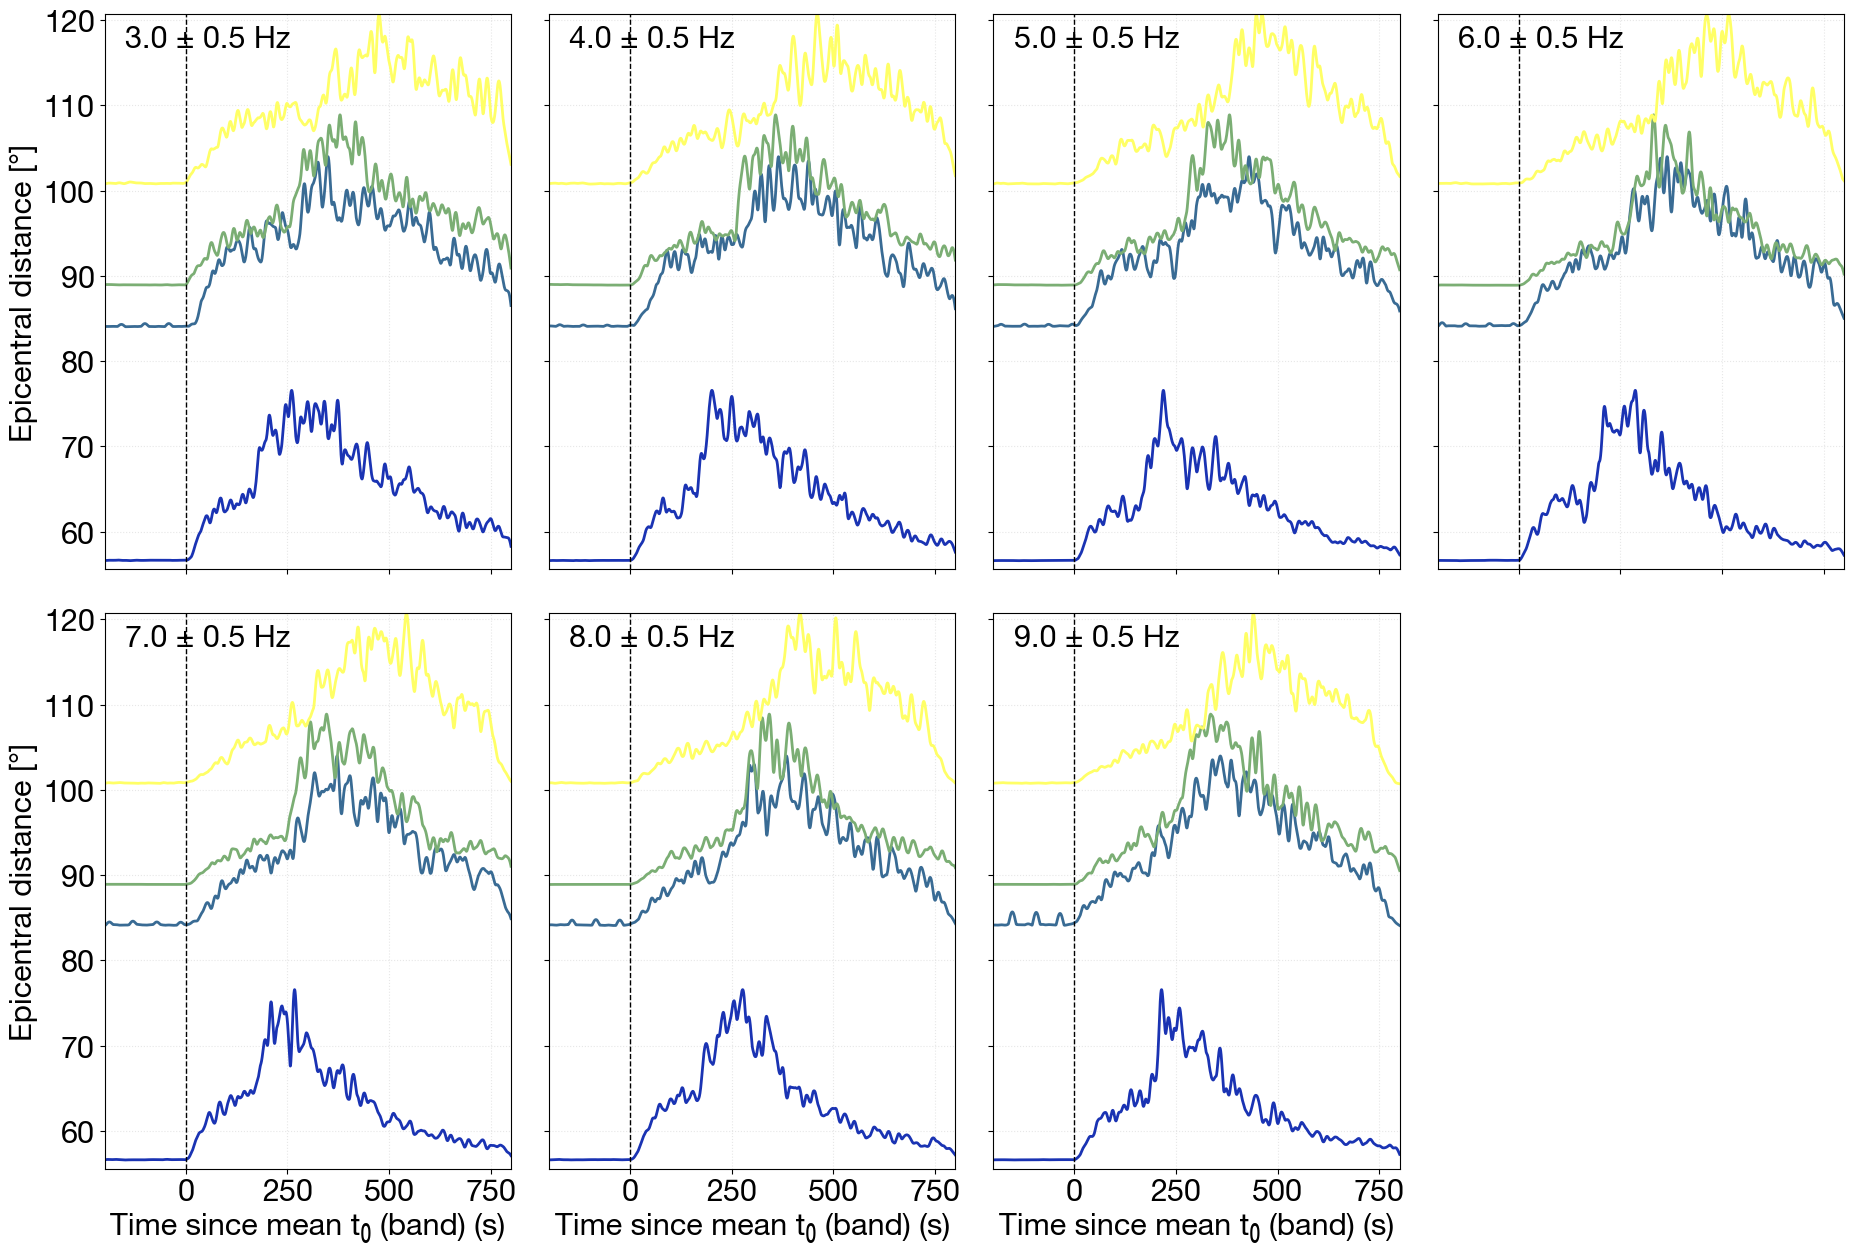

[tol0.75_post2_kneg1_prepos1] Saved: /Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/results/LSQ_Fitting/Single_Plots/Envelope_distance_win20_LOWER_TOL=0.75_MIN_POST=4_K_NEG=0_K_PRE_POS=0.pdf


In [48]:
# ============================================================
# Plot distance-gather RMS(envelope) aligned on band t0_dt_mean
# Match events by: (station, MiniSEED trace starttime) <-> Excel starttime
# Only win_s = 20 seconds
# Color: Batlow, low->high epicentral distance (per band)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window
from cmcrameri import cm as cmc


# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

# Band setup
FC      = 5.0
BANDS   = np.array([3., 4., 5., 6., 7., 8., 9.])
CENTERS = BANDS.copy()
HALF_BW = 0.5
BP_ORDER = 4

# RMS envelope smoothing window (ONLY this)
WIN_S = 20

# Time window around band t0 (seconds)
T_BEFORE = 200
T_AFTER  = 800

# Matching tolerance between MiniSEED trace starttime and Excel starttime (seconds)
STARTTIME_TOL_S = 2.0

# Output
SAVE_DIR = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/results/LSQ_Fitting/Single_Plots/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Selection scenarios (your logic)
SCENARIOS = [
    dict(name="tol0.75_post2_kneg1_prepos1", LOWER_TOL=0.75, MIN_POST=4, K_NEG=0, K_PRE_POS=0),
]

# Plot aesthetics
plt.rcParams.update({
    "font.family": "Helvetica Neue",
    "font.size": 22,
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})


# -------------------------
# SIGNAL HELPERS
# -------------------------
def band_edges(fc, half_bw, fs):
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp  = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms


# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(f"Missing columns in sheet '{sheet}': {missing}\nAvailable: {list(d.columns)}")

    # Parse types
    d["station"] = d["station"].astype(str)
    d["fc_hz"] = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    # starttime: accept strings, datetimes, etc.
    d["starttime_dt"] = pd.to_datetime(d["starttime"], errors="coerce", utc=True)

    # t0_dt_mean must be absolute datetime
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    # distance handling
    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    # keep only relevant bands
    d = d[d["fc_hz"].isin(BANDS)].copy()

    # event key based on Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # compute dt_rel relative to FC per event
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    # drop rows missing dt_rel or key timing fields
    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    dt_mat = (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )
    return dt_mat


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False); continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False); continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False); continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)

t0_lookup = (
    df_long[["event", "band", "t0_dt_mean_dt"]]
    .drop_duplicates(subset=["event", "band"])
    .set_index(["event", "band"])["t0_dt_mean_dt"]
)

dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    name      = cfg["name"]
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f"Kept by dt_rel criteria: {n_kept}/{n_tot}")

    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f" Kept with MiniSEED match: {len(kept_events)}/{n_kept}")
    if not kept_events:
        print(f" No events to plot after MiniSEED matching.")
        continue
    print(f"LOWER_TOL={LOWER_TOL}_MIN_POST={MIN_POST}_K_NEG={K_NEG}_K_PRE_POS={K_PRE_POS}")

    # Build (event, distance) list and sort by distance
    ev_dist = [(ev, float(dist_map.get(ev, np.nan))) for ev in kept_events]
    ev_dist = [(ev, d) for ev, d in ev_dist if np.isfinite(d)]
    ev_dist.sort(key=lambda x: x[1])

    if not ev_dist:
        print(f" No finite distances among kept events.")
        continue

    dist_min = ev_dist[0][1]
    dist_max = ev_dist[-1][1]

    # ------------------------------------------------------------
    # Assign Batlow colors by distance rank (low->high)
    # (No Normalize, no colormap scaling inside plotting)
    # ------------------------------------------------------------
    nE = len(ev_dist)
    if nE == 1:
        frac = np.array([0.5])
    else:
        frac = np.linspace(0.0, 1.0, nE)

    # event -> rgba
    event_color = {ev: cmc.imola(f) for (ev, _), f in zip(ev_dist, frac)}

    # Plot
    AMP_SCALE_DEG = 20  # scale of wiggle in degrees

    fig, axes = plt.subplots(2, 4, figsize=(19, 13), sharex="all", sharey="row")
    axes = axes.flatten()

    for i, fc in enumerate(CENTERS):
        ax = axes[i]

        n_have_t0 = n_plotted = 0

        for ev, dist in ev_dist:
            key = (ev, float(fc))
            if key not in t0_lookup.index:
                continue

            t0_dt = t0_lookup.loc[key]
            if pd.isna(t0_dt):
                continue
            n_have_t0 += 1

            tr = event_to_trace[ev]

            # window around band t0
            t0 = UTCDateTime(pd.Timestamp(t0_dt).to_pydatetime())
            t1, t2 = t0 - T_BEFORE, t0 + T_AFTER

            trc = tr.copy()
            try:
                trc.trim(t1, t2, pad=True, fill_value=0.0)
            except Exception:
                continue

            fs = float(trc.stats.sampling_rate)
            u  = trc.data.astype(float)
            if u.size < 10:
                continue

            t_rel = np.arange(len(u)) / fs - T_BEFORE

            fl, fu = band_edges(fc, HALF_BW, fs)
            _, rms = env_and_rms(u, fs, fl, fu, WIN_S, BP_ORDER)

            max_rms = np.nanmax(rms)
            if not np.isfinite(max_rms) or max_rms <= 0:
                continue

            rms_norm = rms / max_rms
            y = dist + AMP_SCALE_DEG * rms_norm

            ax.plot(
                t_rel, y,
                lw=2,
                color=event_color[ev],
                alpha=1,
            )
            n_plotted += 1

        ax.text(0.05, 0.98, f"{fc:.1f} ± {HALF_BW} Hz",
                ha="left", va="top", transform=ax.transAxes)
        ax.grid(True, ls=":", alpha=0.3)
        ax.axvline(0, color="k", ls="--", lw=1.0)
        ax.set_xlim(-T_BEFORE, T_AFTER)
        ax.set_ylim(dist_min - 1.0, dist_max + 20)

        if i % 4 == 0:
            ax.set_ylabel("Epicentral distance [°]")
        if i >= 4:
            ax.set_xlabel("Time since mean t₀ (band) (s)")

    if len(CENTERS) < 8:
        axes[-1].axis("off")

    # fig.suptitle(
    #     f"{name} | {len(ev_dist)}/{n_tot} events (after match) | win={WIN_S}s | aligned on t0_dt_mean(band)",
    #     y=0.98
    # )
    fig.tight_layout()

    out = os.path.join(SAVE_DIR, f"Envelope_distance_win{WIN_S:02d}_LOWER_TOL={LOWER_TOL}_MIN_POST={MIN_POST}_K_NEG={K_NEG}_K_PRE_POS={K_PRE_POS}.pdf")
    fig.savefig(out, dpi=200)
    plt.show()
    plt.close(fig)

    print(f"[{name}] Saved: {out}")


In [10]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# # -------------------------------------------------------------------
# # EXPECTED TO EXIST IN YOUR NOTEBOOK:
# #   - _diffusion_log_e(tt, A, q, a, s, D): returns log(amp_diff^2)
# #   - diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0): returns amp_total
# # -------------------------------------------------------------------

# def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
#     """Return log(amp_total) stably via logaddexp."""
#     tt = np.asarray(tt, float)
#     x = np.maximum(tt - dt, 1e-3)

#     n0 = np.maximum(float(n0), 1e-30)
#     log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
#     log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

#     return 0.5 * np.logaddexp(log_e, log_n0sq)


# def best_safe_start_compare_log_linear_weighted(
#     t, amp, *, D,
#     t0excel_s,
#     end_after_t0=200.0,
#     safe_start_grid=np.arange(100.0, 301.0, 10.0),
#     maxfev=200000,
#     plot=True,
#     # ---- weighting controls for weighted linear fit
#     weight_mode="prop",     # "prop" => sigma ~ amp (relative error); "floor" => sigma ~ sqrt(amp^2 + n0^2)
#     sigma_floor_mult=1.0,   # sigma minimum = sigma_floor_mult * n0 (prevents crazy weights near the floor)
#     sigma_eps=1e-30,        # absolute epsilon clamp
# ):
#     """
#     Runs 3 fits per safe_start:
#       - LOG-space fit: minimize ||log(amp) - log(model)||^2
#       - LINEAR (unweighted): minimize ||amp - model||^2
#       - LINEAR (weighted): minimize ||(amp - model)/sigma||^2, with sigma chosen by weight_mode

#     Notes:
#       - SSE values are not directly comparable across spaces. Compare shape + params.
#       - Weighted linear SSE returned is SSE_w = sum(((y - yhat)/sigma)^2).
#     """
#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     t0excel_s = float(t0excel_s)
#     fit_end_abs = t0excel_s + float(end_after_t0)

#     bounds = (
#         (1e-30, 1e-12, 1e-12, 1e-3),
#         (1e+03, 1.0,   10.0,  1e6),
#     )

#     scan = []
#     best_log = None
#     best_lin = None
#     best_wlin = None

#     for ss in safe_start_grid:
#         ss = float(ss)
#         if ss >= fit_end_abs:
#             continue

#         # ---- noise floor estimate from [0, ss)
#         noise_mask = (t >= 0.0) & (t < ss) & np.isfinite(amp) & (amp > 0)
#         if not np.any(noise_mask):
#             continue
#         n0 = float(np.mean(amp[noise_mask]))
#         n0 = max(n0, 1e-30)

#         # ---- fit window [ss, t0 + end_after_t0]
#         fit_mask = (t >= ss) & (t <= fit_end_abs) & np.isfinite(amp) & (amp > 0)
#         t_fit = t[fit_mask]
#         amp_fit = amp[fit_mask]
#         if t_fit.size < 20:
#             continue

#         # ---- initial guess
#         A0 = float(np.median(amp_fit))
#         q0 = 0.98
#         a0 = 5e-3
#         s0 = max(D / 4.0, 1e-2)
#         p0 = (A0, q0, a0, s0)

#         # Common model in linear amplitude domain
#         def f_lin(tt, A, q, a, s):
#             return diffusion_amp_floor(tt, A, q, a, s, D, n0)

#         # -----------------------
#         # LOG-SPACE FIT
#         # -----------------------
#         y_log = np.log(amp_fit)

#         def f_log(tt, A, q, a, s):
#             return diffusion_logamp_floor(tt, A, q, a, s, D, n0)

#         popt_log = pcov_log = None
#         sse_log = np.inf
#         try:
#             popt_log, pcov_log = curve_fit(
#                 f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev
#             )
#             ylog_pred = f_log(t_fit, *popt_log)
#             sse_log = float(np.sum((y_log - ylog_pred) ** 2))
#         except Exception:
#             pass

#         # -----------------------
#         # LINEAR-SPACE FIT (UNWEIGHTED)
#         # -----------------------
#         y_lin = amp_fit
#         popt_lin = pcov_lin = None
#         sse_lin = np.inf
#         try:
#             popt_lin, pcov_lin = curve_fit(
#                 f_lin, t_fit, y_lin, p0=p0, bounds=bounds, maxfev=maxfev
#             )
#             ylin_pred = f_lin(t_fit, *popt_lin)
#             sse_lin = float(np.sum((y_lin - ylin_pred) ** 2))
#         except Exception:
#             pass

#         # -----------------------
#         # LINEAR-SPACE FIT (WEIGHTED)
#         # -----------------------
#         # Build sigma (pointwise standard deviation model).
#         # "prop": sigma ~ amp (relative-error model, like log-fit)
#         # "floor": sigma ~ sqrt(amp^2 + n0^2) (keeps weights sane near floor)
#         if weight_mode == "prop":
#             sigma = np.maximum(amp_fit, sigma_floor_mult * n0)
#         elif weight_mode == "floor":
#             sigma = np.sqrt(np.maximum(amp_fit, 0.0)**2 + (sigma_floor_mult * n0)**2)
#         else:
#             raise ValueError("weight_mode must be 'prop' or 'floor'")

#         sigma = np.maximum(sigma, sigma_eps)

#         popt_wlin = pcov_wlin = None
#         sse_wlin = np.inf
#         try:
#             popt_wlin, pcov_wlin = curve_fit(
#                 f_lin, t_fit, y_lin,
#                 p0=p0, bounds=bounds, maxfev=maxfev,
#                 sigma=sigma, absolute_sigma=False
#             )
#             y_wpred = f_lin(t_fit, *popt_wlin)
#             sse_wlin = float(np.sum(((y_lin - y_wpred) / sigma) ** 2))
#         except Exception:
#             pass

#         if (not np.isfinite(sse_log)) and (not np.isfinite(sse_lin)) and (not np.isfinite(sse_wlin)):
#             continue

#         row = dict(
#             safe_start=ss,
#             n0=n0,
#             fit_start=ss,
#             fit_end=fit_end_abs,
#             t0excel_s=t0excel_s,
#             end_after_t0=float(end_after_t0),

#             popt_log=popt_log, pcov_log=pcov_log, sse_log=sse_log,
#             popt_lin=popt_lin, pcov_lin=pcov_lin, sse_lin=sse_lin,
#             popt_wlin=popt_wlin, pcov_wlin=pcov_wlin, sse_wlin=sse_wlin,

#             weight_mode=weight_mode,
#             sigma_floor_mult=float(sigma_floor_mult),
#         )
#         scan.append(row)

#         if np.isfinite(sse_log) and ((best_log is None) or (sse_log < best_log["sse_log"])):
#             best_log = row
#         if np.isfinite(sse_lin) and ((best_lin is None) or (sse_lin < best_lin["sse_lin"])):
#             best_lin = row
#         if np.isfinite(sse_wlin) and ((best_wlin is None) or (sse_wlin < best_wlin["sse_wlin"])):
#             best_wlin = row

#     if not scan:
#         raise RuntimeError("No successful fits in scan.")

#     # -----------------------
#     # PLOTTING
#     # -----------------------
#     if plot:
#         ss_vals = [r["safe_start"] for r in scan]
#         sse_log_vals  = [r["sse_log"]  for r in scan]
#         sse_lin_vals  = [r["sse_lin"]  for r in scan]
#         sse_wlin_vals = [r["sse_wlin"] for r in scan]

#         plt.figure(figsize=(10, 4))
#         plt.plot(ss_vals, sse_log_vals,  marker="o", label="Log-space SSE")
#         plt.plot(ss_vals, sse_lin_vals,  marker="o", label="Linear SSE")
#         plt.plot(ss_vals, sse_wlin_vals, marker="o", label=f"Weighted linear SSE (mode={weight_mode})")

#         if best_log is not None:
#             plt.axvline(best_log["safe_start"],  color="r", ls="--", alpha=0.6,
#                         label=f"Best log ss={best_log['safe_start']:.1f}s")
#         if best_lin is not None:
#             plt.axvline(best_lin["safe_start"],  color="b", ls="--", alpha=0.6,
#                         label=f"Best lin ss={best_lin['safe_start']:.1f}s")
#         if best_wlin is not None:
#             plt.axvline(best_wlin["safe_start"], color="g", ls="--", alpha=0.6,
#                         label=f"Best wlin ss={best_wlin['safe_start']:.1f}s")

#         plt.axvline(t0excel_s, color="0.4", ls=":", label="t0excel")
#         plt.xlabel("safe_start (s)")
#         plt.ylabel("SSE (different definitions!)")
#         plt.title("Compare log vs linear vs weighted-linear across safe_start")
#         plt.grid(True, alpha=0.3)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

#         # ---- best-fit overlays (3 rows: log / lin / wlin) x (linear view, semilogy)
#         fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

#         def plot_best(row, popt_key, r, title):
#             if row is None or row[popt_key] is None:
#                 axes[r, 0].set_title(title + " (no fit)")
#                 axes[r, 1].set_title(title + " (no fit)")
#                 return

#             A, q, a, s = row[popt_key]
#             n0 = row["n0"]
#             t_model = np.linspace(row["fit_start"], row["fit_end"], 1200)
#             amp_model = diffusion_amp_floor(t_model, A, q, a, s, D, n0)

#             # linear
#             axes[r, 0].plot(t, amp, lw=1, color="k")
#             axes[r, 0].plot(t_model, amp_model, lw=2)
#             axes[r, 0].axvline(row["fit_start"], ls="--", color="0.3")
#             axes[r, 0].axvline(row["fit_end"],   ls="--", color="0.3")
#             axes[r, 0].axvline(t0excel_s,        ls=":",  color="0.4")
#             axes[r, 0].set_title(title + " (linear view)")
#             axes[r, 0].grid(True, alpha=0.3)

#             # semilogy
#             axes[r, 1].semilogy(t, amp, lw=1, color="k")
#             axes[r, 1].semilogy(t_model, amp_model, lw=2)
#             axes[r, 1].axvline(row["fit_start"], ls="--", color="0.3")
#             axes[r, 1].axvline(row["fit_end"],   ls="--", color="0.3")
#             axes[r, 1].axvline(t0excel_s,        ls=":",  color="0.4")
#             axes[r, 1].set_title(title + " (semilogy view)")
#             axes[r, 1].grid(True, which="both", alpha=0.3)

#         plot_best(best_log,  "popt_log",  0, "Best LOG-fit")
#         plot_best(best_lin,  "popt_lin",  1, "Best LINEAR-fit")
#         plot_best(best_wlin, "popt_wlin", 2, f"Best WEIGHTED-LINEAR-fit ({weight_mode})")

#         for rr in range(3):
#             axes[rr, 0].set_ylabel("Amplitude")
#         axes[2, 0].set_xlabel("Time (s)")
#         axes[2, 1].set_xlabel("Time (s)")
#         plt.tight_layout()
#         plt.show()

#     return best_log, best_lin, best_wlin, scan


# def print_best(label, best, popt_key, sse_key):
#     if best is None or best.get(popt_key) is None:
#         print(f"\n=== BEST {label} ===")
#         print("No successful fit.")
#         return

#     A, q, a, s = best[popt_key]
#     n0 = best["n0"]

#     print(f"\n=== BEST {label} ===")
#     print(f"safe_start     : {best['safe_start']:.3f} s")
#     print(f"fit_window     : {best['fit_start']:.3f} → {best['fit_end']:.3f} s")
#     print(f"t0excel_s      : {best['t0excel_s']:.3f} s")
#     print(f"end_after_t0   : {best['end_after_t0']:.3f} s")
#     if "weight_mode" in best:
#         print(f"weight_mode    : {best['weight_mode']}")
#         print(f"sigma_floor_mult: {best['sigma_floor_mult']:.3f}")
#     print("")
#     print("Parameters:")
#     print(f"A               = {A:.6e}")
#     print(f"q               = {q:.6f}")
#     print(f"a               = {a:.6e}")
#     print(f"s               = {s:.6f}")
#     print(f"n0 (noise floor)= {n0:.6e}")
#     print("")
#     print(f"{sse_key}       = {best[sse_key]:.6e}")


# # -------------------------
# # Example usage (matches your style)
# # -------------------------
# after_t0 = 400

# best_log, best_lin, best_wlin, scan = best_safe_start_compare_log_linear_weighted(
#     t, rms,
#     D=D_km,
#     t0excel_s=t0_line_band,
#     end_after_t0=after_t0,
#     safe_start_grid=np.arange(10, t0_line_band - 60, 10),
#     plot=True,
#     weight_mode="floor",       # try "prop" and "floor"
#     sigma_floor_mult=3.0,
# )

# print_best("LOG",            best_log,  "popt_log",  "sse_log")
# print_best("LINEAR",         best_lin,  "popt_lin",  "sse_lin")
# print_best("WEIGHTED LINEAR", best_wlin, "popt_wlin", "sse_wlin")

In [11]:
# from typing import List, Sequence, Tuple

# def load_seismogram_txt(path: str) -> Tuple[np.ndarray, np.ndarray]:
#    times: List[UTCDateTime] = []
#    data: List[float] = []
#    with open(path, "r", encoding="utf-8") as fh:
#        fh.readline()  # discard header
#        for line in fh:
#            parts = line.split()
#            if len(parts) < 2:
#                continue
#            try:
#                times.append(UTCDateTime(parts[0]))
#                data.append(float(parts[1]))
#            except Exception:
#                continue
#    if len(data) < 2:
#        raise RuntimeError(f"Not enough samples in {path}")
#    return np.asarray(times, dtype=object), np.asarray(data, dtype=np.float64)

# def _to_log10_ratio(x: np.ndarray, floor: float = 1e-12) -> np.ndarray:
#    pos = x[x > 0]
#    f = floor if pos.size == 0 else min(floor, max(1e-300, 0.1 * np.min(pos)))
#    return np.log10(np.clip(x, f, None))

# def seconds_since_start(times: Sequence[UTCDateTime]) -> np.ndarray:
#    t0 = times[0]
#    return np.array([t - t0 for t in times], dtype=np.float64)
# impact_seismogram_path = "/Users/ramonmargarit/Desktop/seismogram_2.0.txt"

In [12]:
# from typing import List, Sequence, Tuple
# import numpy as np
# import matplotlib.pyplot as plt
# from obspy import UTCDateTime


# def load_seismogram_txt(path: str) -> Tuple[np.ndarray, np.ndarray]:
#     times: List[UTCDateTime] = []
#     data: List[float] = []

#     with open(path, "r", encoding="utf-8") as fh:
#         header = fh.readline()  # discard header
#         for line in fh:
#             parts = line.split()
#             if len(parts) < 2:
#                 continue
#             try:
#                 times.append(UTCDateTime(parts[0]))
#                 data.append(float(parts[1]))
#             except Exception:
#                 continue

#     if len(data) < 2:
#         raise RuntimeError(f"Not enough samples in {path}")

#     # Keep UTCDateTime objects (dtype=object), amplitudes as float64
#     return np.asarray(times, dtype=object), np.asarray(data, dtype=np.float64)


# def _to_log10_ratio(x: np.ndarray, floor: float = 1e-12) -> np.ndarray:
#     # choose a floor relative to smallest positive sample if possible
#     pos = x[x > 0]
#     f = floor if pos.size == 0 else min(floor, max(1e-300, 0.1 * np.min(pos)))
#     return np.log10(np.clip(x, f, None))


# def seconds_since_start(times: Sequence[UTCDateTime]) -> np.ndarray:
#     t0 = times[0]
#     return np.array([t - t0 for t in times], dtype=np.float64)


# impact_seismogram_path = "/Users/ramonmargarit/Desktop/seismogram_2.0.txt"

# times, data = load_seismogram_txt(impact_seismogram_path)

# # keep original full arrays for consistent masking
# t_rel_full = seconds_since_start(times)
# data_full = data

# valid_mask = np.isfinite(t_rel_full) & np.isfinite(data_full)

# # two masks on full arrays
# trim_mask = (t_rel_full >= 300) & (t_rel_full <= 4000) & valid_mask
# early_mask = (t_rel_full <= 300) & valid_mask

# # trimmed window
# t_rel = t_rel_full[trim_mask]
# data = data_full[trim_mask]

# # early window
# early_t_rel = t_rel_full[early_mask]
# early_data = data_full[early_mask]

# data_log = _to_log10_ratio(data, 1)
# early_data_log = _to_log10_ratio(early_data, 1)

# plt.figure(figsize=(10, 5))
# plt.plot(t_rel_full, data_full, color="red", linewidth=1.0, label="log10(amplitude)")
# plt.legend()
# plt.title("impact")
# plt.xlabel("Time since start (s)")
# plt.ylabel("(Amplitude)")
# plt.tight_layout()
# plt.show()

In [13]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import least_squares


# def _diffusion_log_e(tt, A, q, a, s, D):
#     tt = np.asarray(tt, float)
#     tt = np.maximum(tt, 1e-12)

#     q = np.clip(q, 1e-12, 1 - 1e-12)
#     a = np.maximum(a, 1e-12)
#     s = np.maximum(s, 1e-12)
#     A = np.maximum(A, 1e-30)

#     return (
#         2.0 * np.log(A)
#         + (a * tt) * np.log(q)
#         - np.log(a * tt)
#         - (D**2) / (s**2 * a * tt)
#     )


# def diffusion_logamp_floor(tt, A, q, a, s, D, n0):
#     log_sig2 = _diffusion_log_e(tt, A, q, a, s, D)
#     n0 = max(float(n0), 1e-30)
#     return 0.5 * np.logaddexp(log_sig2, 2.0 * np.log(n0))


# def diffusion_amp_floor(tt, A, q, a, s, D, n0):
#     log_sig2 = _diffusion_log_e(tt, A, q, a, s, D)
#     sig2 = np.exp(log_sig2)
#     n0 = max(float(n0), 1e-30)
#     return np.sqrt(sig2 + n0**2)


# def grid_fit_window_search(
#     t, amp, *, D,
#     fit_start_grid,
#     fit_end_grid,
#     noise_window=(0.0, 300.0),
#     noise_percentile=20,
#     min_noise_n=20,
#     min_fit_n=80,
#     max_nfev=200000,
#     loss="linear",
#     plot=True,
# ):
#     """
#     Grid-search over (fit_start, fit_end). For each window:
#       1) estimate n0 from noise_window (fixed)
#       2) LSQ fit (A,q,a,s) on data within [fit_start, fit_end] using masks (no trimming)
#       3) compute SSE in log-space over the active fit points
#     Select configuration that minimizes SSE.
#     """
#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     finite = np.isfinite(t) & np.isfinite(amp)
#     positive = amp > 0.0

#     # --- noise floor n0 from fixed noise window
#     n_lo, n_hi = map(float, noise_window)
#     noise_mask = finite & positive & (t >= n_lo) & (t < n_hi)
#     noise_n = int(np.count_nonzero(noise_mask))
#     if noise_n < min_noise_n:
#         raise RuntimeError(f"Not enough noise points ({noise_n} < {min_noise_n}) in noise_window={noise_window}")

#     n0 = float(np.nanpercentile(np.where(noise_mask, amp, np.nan), noise_percentile))
#     if not np.isfinite(n0) or n0 <= 0:
#         raise RuntimeError("Failed to estimate a valid noise floor n0.")
#     n0 = max(n0, 1e-30)

#     # bounds for (A,q,a,s)
#     lb = np.array([1e-30, 1e-6,   1e-12, 1e-6], float)
#     ub = np.array([1e+30, 1-1e-6, 1e+3,  1e+6], float)

#     # precompute global y = log(amp) where valid (we'll mask per-window)
#     y_full = np.full_like(amp, np.nan, dtype=float)
#     valid_for_log = finite & positive
#     y_full[valid_for_log] = np.log(amp[valid_for_log])

#     results = []
#     best = None

#     fit_start_grid = np.asarray(fit_start_grid, float)
#     fit_end_grid = np.asarray(fit_end_grid, float)

#     for fs in fit_start_grid:
#         for fe in fit_end_grid:
#             if not np.isfinite(fs) or not np.isfinite(fe) or fe <= fs:
#                 continue

#             fit_mask = finite & positive & (t >= fs) & (t <= fe)
#             fit_n = int(np.count_nonzero(fit_mask))
#             if fit_n < min_fit_n:
#                 continue

#             # init guess from window data
#             A0 = float(np.nanmedian(np.where(fit_mask, amp, np.nan)))
#             if not np.isfinite(A0) or A0 <= 0:
#                 continue

#             x0 = np.array([A0, 0.98, 5e-3, max(D/4.0, 1e-2)], float)

#             # weights: 1 inside window, 0 outside
#             w = np.zeros_like(t, dtype=float)
#             w[fit_mask] = 1.0

#             def residuals(x):
#                 A, q, a, s = x
#                 yhat = diffusion_logamp_floor(t, A, q, a, s, D, n0)
#                 r = np.zeros_like(t, dtype=float)

#                 active = (w > 0) & np.isfinite(y_full) & np.isfinite(yhat)
#                 r[active] = (y_full[active] - yhat[active])
#                 return r

#             try:
#                 res = least_squares(
#                     residuals, x0,
#                     bounds=(lb, ub),
#                     max_nfev=max_nfev,
#                     loss=loss,
#                     f_scale=1.0
#                 )
#             except Exception:
#                 continue

#             if not res.success:
#                 continue

#             r = residuals(res.x)
#             sse = float(np.sum(r**2))  # includes zeros outside window

#             rec = {
#                 "fit_start": float(fs),
#                 "fit_end": float(fe),
#                 "n_fit": fit_n,
#                 "SSE": sse,
#                 "popt": res.x,
#                 "n0": n0,
#                 "success": True,
#                 "message": res.message,
#             }
#             results.append(rec)

#             if (best is None) or (sse < best["SSE"]):
#                 best = rec

#     if best is None:
#         raise RuntimeError("No successful fits in grid search. Expand grids or lower min_fit_n.")

#     if plot:
#         # --- plot SSE heatmap-like scatter (fs vs fe)
#         fs_vals = np.array([r["fit_start"] for r in results], float)
#         fe_vals = np.array([r["fit_end"] for r in results], float)
#         sse_vals = np.array([r["SSE"] for r in results], float)

#         plt.figure(figsize=(7, 5))
#         sc = plt.scatter(fs_vals, fe_vals, c=sse_vals, s=35)
#         plt.colorbar(sc, label="log-space SSE")
#         plt.scatter([best["fit_start"]], [best["fit_end"]], s=120, marker="x")
#         plt.xlabel("fit_start (s)")
#         plt.ylabel("fit_end (s)")
#         plt.title("Grid search over fit window")
#         plt.tight_layout()
#         plt.show()

#         # --- plot best fit
#         A, q, a, s = best["popt"]
#         finite_t = np.isfinite(t)
#         fs = best["fit_start"]
#         fe = best["fit_end"]

#         t_model = np.linspace(fs, fe, 1500)
#         amp_model = diffusion_amp_floor(t_model, A, q, a, s, D, best["n0"])

#         fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

#         axes[0].plot(t, amp, color="k", lw=1, label="Observed")
#         axes[0].plot(t_model, amp_model, lw=2, label="Best Fit")
#         axes[0].axvline(best["fit_start"], ls="--", color="0.3")
#         axes[0].axvline(best["fit_end"], ls="--", color="0.3")
#         axes[0].set_title("Linear")
#         axes[0].set_xlabel("Time (s)")
#         axes[0].set_xlim(0, 3000)
#         axes[0].set_ylabel("Amplitude")
#         axes[0].grid(True, alpha=0.3)
#         axes[0].legend()

#         axes[1].semilogy(t, amp, color="k", lw=1, label="Observed")
#         axes[1].semilogy(t_model, amp_model, lw=2, label="Best Fit")
#         axes[1].axvline(best["fit_start"], ls="--", color="0.3")
#         axes[1].axvline(best["fit_end"], ls="--", color="0.3")
#         axes[1].set_title("Semilogy")
#         axes[1].set_xlabel("Time (s)")
#         axes[1].set_xlim(0, 3000)
#         axes[1].grid(True, which="both", alpha=0.3)
#         axes[1].legend()

#         plt.tight_layout()
#         plt.show()

#     return best, results


# # ------------------ usage example ------------------
# best, all_results = grid_fit_window_search(
#     t_rel_full, data_full,
#     D=140,
#     fit_start_grid=np.arange(250, 300, 30),
#     fit_end_grid=np.arange(1000, 2000, 100),
#     noise_window=(0, 300),
#     plot=True,
# )
# print(best)

In [14]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import least_squares


# # -------------------------
# # model constants
# # -------------------------

# T_EPS_SEC = 1.0

# P_LOWER = np.array([-6.0, 0.01, 0.01, 0.1], float)   # log10_A2, q0, alpha, sigma
# P_UPPER = np.array([15.0, 10.0, 5.0, 500.0], float)

# P0 = np.array([5.0, 5.0, 1.0, 100.0], float)


# # -------------------------
# # helper functions
# # -------------------------

# import numpy as np
# import pandas as pd

# def grid_search_fit_window(
#     t_env, amp_for_fit, *,
#     D,
#     noise_window,
#     fit_start_center,
#     fit_start_halfwidth=40,
#     fit_start_step=1,
#     fit_end_range=(400, 500, 20),   # (start, stop, step) like np.arange
#     min_window_s=60,                # require at least this much duration
#     plot_best=False,
#     verbose=False,
# ):
#     """
#     Grid-search (fit_start, fit_end) to minimize least-squares RSS returned by waterlevelcode().
#     Returns: best_fit_dict, grid_df (all trials)
#     """

#     t_env = np.asarray(t_env, float)
#     amp_for_fit = np.asarray(amp_for_fit, float)

#     fit_starts = np.arange(fit_start_center - fit_start_halfwidth,
#                            fit_start_center + fit_start_halfwidth + 1,
#                            fit_start_step, dtype=float)

#     fe0, fe1, fe_step = fit_end_range
#     fit_ends = np.arange(fe0, fe1, fe_step, dtype=float)

#     rows = []
#     best = None
#     best_rss = np.inf

#     for fs in fit_starts:
#         for fe in fit_ends:
#             if fe <= fs + min_window_s:
#                 continue

#             try:
#                 fit = waterlevelcode(
#                     t_env, amp_for_fit,
#                     D=D,
#                     fit_start=float(fs),
#                     fit_end=float(fe),
#                     noise_window=noise_window,
#                     plot=False,   # never plot during grid search
#                 )
#                 rss = fit.get("rss", np.nan)
#                 ok = bool(fit.get("success", False)) and np.isfinite(rss)

#             except Exception as e:
#                 # record failure (optional)
#                 rows.append({
#                     "fit_start": fs, "fit_end": fe,
#                     "success": False, "rss": np.nan,
#                     "error": str(e)[:200],
#                 })
#                 continue

#             rows.append({
#                 "fit_start": fs, "fit_end": fe,
#                 "success": ok, "rss": float(rss),
#                 "q0": fit.get("q0", np.nan),
#                 "alpha": fit.get("alpha", np.nan),
#                 "sigma": fit.get("sigma", np.nan),
#                 "log10_A2": fit.get("log10_A2", np.nan),
#             })

#             if ok and rss < best_rss:
#                 best_rss = rss
#                 best = fit

#         if verbose:
#             print(f"done fit_start={fs}")

#     grid_df = pd.DataFrame(rows)

#     if best is None:
#         raise RuntimeError("Grid search found no successful fits.")

#     if plot_best:
#         # re-run best with plot=True
#         best = waterlevelcode(
#             t_env, amp_for_fit,
#             D=D,
#             fit_start=best["fit_start"],
#             fit_end=best["fit_end"],
#             noise_window=noise_window,
#             plot=True,
#         )

#     return best, grid_df

# def log10_envelope(x):
#     x = np.asarray(x, float)
#     pos = x[x > 0]

#     if pos.size == 0:
#         floor = 1e-12
#     else:
#         floor = min(1e-12, max(1e-300, 0.1 * np.min(pos)))

#     return np.log10(np.clip(x, floor, None))


# def coda_log10_model(t, log10_A2, q0, alpha, sigma_km, D_km, water_level):

#     t = np.asarray(t, float)
#     t = np.clip(t, T_EPS_SEC, None)

#     A2 = 10 ** log10_A2

#     q = 1 - 10 ** (-q0)
#     q = np.clip(q, 1e-6, 0.999999)

#     sigma_km = max(1e-3, sigma_km)

#     S = (D_km / sigma_km) ** 2

#     inv_alpha_t = 1 / (alpha * t)

#     exponent = -inv_alpha_t * S

#     power_term = np.exp(alpha * t * np.log(q))

#     e = A2 * power_term * inv_alpha_t * np.exp(exponent)

#     e = np.clip(e, water_level, None)

#     return np.log10(e)


# # -------------------------
# # main fitting function
# # -------------------------

# def waterlevelcode(
#         t,
#         amp,
#         *,
#         D,
#         fit_start,
#         fit_end,
#         noise_window=(0, 300),
#         min_noise_n=20,
#         min_fit_n=80,
#         plot=True,
# ):

#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     finite = np.isfinite(t) & np.isfinite(amp)
#     positive = amp > 0

#     # -------------------------
#     # compute log envelope
#     # -------------------------

#     env_log = log10_envelope(np.abs(amp))

#     # -------------------------
#     # water level
#     # -------------------------

#     n_lo, n_hi = noise_window

#     noise_mask = finite & positive & (t >= n_lo) & (t < n_hi)

#     if np.sum(noise_mask) < min_noise_n:
#         raise RuntimeError("Not enough points in noise window")

#     noise_log = np.mean(env_log[noise_mask])

#     water_level = 10 ** noise_log

#     # -------------------------
#     # fit window
#     # -------------------------

#     fit_mask = finite & positive & (t >= fit_start) & (t <= fit_end)

#     if np.sum(fit_mask) < min_fit_n:
#         raise RuntimeError("Not enough points in fit window")

#     t_fit = t[fit_mask] - fit_start
#     y_fit = env_log[fit_mask]

#     # -------------------------
#     # residual function
#     # -------------------------

#     def residuals(p):

#         y_model = coda_log10_model(
#             t_fit,
#             p[0],
#             p[1],
#             p[2],
#             p[3],
#             D,
#             water_level
#         )

#         return y_model - y_fit

#     # -------------------------
#     # optimization
#     # -------------------------

#     result = least_squares(
#         residuals,
#         P0,
#         bounds=(P_LOWER, P_UPPER),
#         method="trf",
#         max_nfev=2000,
#     )
#     rss = 2.0 * result.cost


#     if not result.success:
#         raise RuntimeError("Fit did not converge")

#     log10_A2, q0, alpha, sigma = result.x

#     # -------------------------
#     # model curve for plotting
#     # -------------------------

#     t_model = np.linspace(fit_start, fit_end, 2000)

#     t_rel = t_model - fit_start

#     y_model = coda_log10_model(
#         t_rel,
#         log10_A2,
#         q0,
#         alpha,
#         sigma,
#         D,
#         water_level
#     )

#     amp_model = 10 ** y_model

#     # -------------------------
#     # plotting
#     # -------------------------

#     if plot:

#         fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

#         axes[0].plot(t, amp, color="k", lw=1, label="Observed")
#         axes[0].plot(t_model, amp_model, lw=2, label="WaterLevel Fit")

#         axes[0].axvline(fit_start, ls="--")
#         axes[0].axvline(fit_end, ls="--")

#         axes[0].set_xlabel("Time (s)")
#         axes[0].set_ylabel("Amplitude")
#         axes[0].set_title("Linear")
#         axes[0].grid(True, alpha=0.3)
#         axes[0].legend()
#         axes[0].set_xlim(-200, 1000)
#         axes[1].semilogy(t, amp, color="k", lw=1)
#         axes[1].semilogy(t_model, amp_model, lw=2)

#         axes[1].axvline(fit_start, ls="--")
#         axes[1].axvline(fit_end, ls="--")
#         axes[1].set_xlim(-200, 1000)
#         axes[1].set_xlabel("Time (s)")
#         axes[1].set_title("Semilogy")
#         axes[1].grid(True, which="both", alpha=0.3)

#         plt.tight_layout()
#         plt.show()

#     return {
#         "log10_A2": log10_A2,
#         "q0": q0,
#         "alpha": alpha,
#         "sigma": sigma,
#         "water_level": water_level,
#         "fit_start": fit_start,
#         "fit_end": fit_end,
#         "success": result.success,
#         "message": result.message,
#         "rss": rss,
#         "cost": float(result.cost),
#     }
# result = waterlevelcode(
#     t_rel_full,
#     data_full,
#     D=140,
#     fit_start=250,
#     fit_end=1200,
#     noise_window=(0,300),
#     plot=True
# )

# best_fit, grid = grid_search_fit_window(
#     t_env, amp_for_fit,
#     D=D_km,
#     noise_window=noise_window,
#     fit_start_center=fit_start,          # your nominal start (e.g., 0)
#     fit_start_halfwidth=40,
#     fit_start_step=1,
#     fit_end_range=(400, 500, 20),
#     min_window_s=80,                     # match your min_fit_n intent roughly
#     plot_best=True,                      # show only the best
# )

# print(result)

Chosen event: 1971-05-20 17:16:10.013000+00:00__S14
Chosen row:
 event       1971-05-20 17:16:10.013000+00:00__S14
time_utc         1971-05-20 17:29:00.023000+00:00
station                                       S14
epi_deg                                      46.0
Name: 0, dtype: object


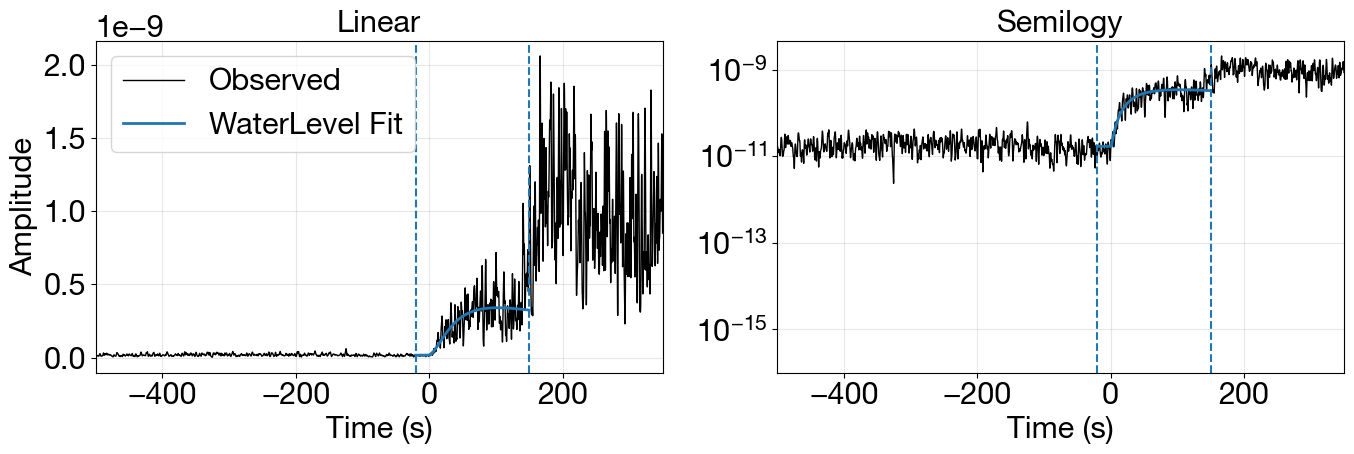

RuntimeError: Missing t0 for event=1971-05-20 17:16:10.013000+00:00__S14, band=4.0 in t0_mat.

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import least_squares
# # -------------------------
# # Your selector (as given)
# # -------------------------
# def select_trace_and_event_by_epicentral_distance(
#     out_df,
#     event_to_trace,
#     *,
#     target_deg,
#     tol_deg=0.01,
#     mode="closest",
#     event_col="event",
#     dist_col=None
# ):
#     d = out_df.copy()

#     if dist_col is None:
#         if "epi_deg" in d.columns:
#             dist_col = "epi_deg"
#         elif "distance_deg" in d.columns:
#             dist_col = "distance_deg"
#         else:
#             raise KeyError("out_df must contain 'epi_deg' or 'distance_deg'")

#     d[dist_col] = pd.to_numeric(d[dist_col], errors="coerce")
#     d = d[d[dist_col].notna()]
#     if d.empty:
#         return None, None, None

#     win = d[(d[dist_col] >= target_deg - tol_deg) & (d[dist_col] <= target_deg + tol_deg)]
#     if win.empty:
#         return None, None, None

#     if mode == "closest":
#         idx = (win[dist_col] - target_deg).abs().idxmin()
#     elif mode == "min":
#         idx = win[dist_col].idxmin()
#     elif mode == "max":
#         idx = win[dist_col].idxmax()
#     else:
#         raise ValueError(f"Unknown mode: {mode}")

#     if event_col not in win.columns:
#         raise KeyError(f"out_df must contain '{event_col}' to map to event_to_trace")

#     chosen_row = win.loc[idx]
#     chosen_event = chosen_row[event_col]
#     tr = event_to_trace.get(chosen_event)

#     return tr, chosen_event, chosen_row

# def log10_envelope(x):
#     x = np.asarray(x, float)
#     pos = x[x > 0]

#     if pos.size == 0:
#         floor = 1e-12
#     else:
#         floor = min(1e-12, max(1e-300, 0.1 * np.min(pos)))

#     return np.log10(np.clip(x, floor, None))

# def coda_log10_model(t, log10_A2, q0, alpha, sigma_km, D_km, water_level):

#     t = np.asarray(t, float)
#     t = np.clip(t, T_EPS_SEC, None)

#     A2 = 10 ** log10_A2

#     q = 1 - 10 ** (-q0)
#     q = np.clip(q, 1e-6, 0.999999)

#     sigma_km = max(1e-3, sigma_km)

#     S = (D_km / sigma_km) ** 2

#     inv_alpha_t = 1 / (alpha * t)

#     exponent = -inv_alpha_t * S

#     power_term = np.exp(alpha * t * np.log(q))

#     e = A2 * power_term * inv_alpha_t * np.exp(exponent)

#     e = np.clip(e, water_level, None)

#     return np.log10(e)


# # -------------------------
# def band_edges(fc, half_bw, fs):
#     fl = max(fc - half_bw, 0.001)
#     fu = min(fc + half_bw, 0.99 * fs / 2)
#     return fl, fu

# def env_and_rms(x, fs, fl, fu, win_s, order):
#     sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
#     bp  = sosfiltfilt(sos, x)
#     env = np.abs(hilbert(bp))

#     N = int(round(win_s * fs)) | 1  # odd length
#     w = get_window("hann", N)
#     w = w / w.sum()

#     rms = np.sqrt(np.convolve(env**2, w, mode="same"))
#     return env, rms

# T_EPS_SEC = 1.0

# P_LOWER = np.array([-16.0, 0.01, 0.01, 0.1], float)   # log10_A2, q0, alpha, sigma
# P_UPPER = np.array([15.0, 10.0, 50.0, 900.0], float)

# P0 = np.array([15.0, 5.0, 1.0, 100.0], float)


# def waterlevelcode(
#         t,
#         amp,
#         *,
#         D,
#         fit_start,
#         fit_end,
#         noise_window=(0, 300),
#         min_noise_n=20,
#         min_fit_n=80,
#         plot=True,
# ):

#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     finite = np.isfinite(t) & np.isfinite(amp)
#     positive = amp > 0

#     # -------------------------
#     # compute log envelope
#     # -------------------------

#     env_log = log10_envelope(np.abs(amp))

#     # -------------------------
#     # water level
#     # -------------------------

#     n_lo, n_hi = noise_window

#     noise_mask = finite & positive & (t >= n_lo) & (t < n_hi)

#     if np.sum(noise_mask) < min_noise_n:
#         raise RuntimeError("Not enough points in noise window")

#     noise_log = np.mean(env_log[noise_mask])

#     water_level = 10 ** noise_log

#     # -------------------------
#     # fit window
#     # -------------------------

#     fit_mask = finite & positive & (t >= fit_start) & (t <= fit_end)

#     if np.sum(fit_mask) < min_fit_n:
#         raise RuntimeError("Not enough points in fit window")

#     t_fit = t[fit_mask] - fit_start
#     y_fit = env_log[fit_mask]

#     # -------------------------
#     # residual function
#     # -------------------------

#     def residuals(p):

#         y_model = coda_log10_model(
#             t_fit,
#             p[0],
#             p[1],
#             p[2],
#             p[3],
#             D,
#             water_level
#         )

#         return y_model - y_fit

#     # -------------------------
#     # optimization
#     # -------------------------

#     result = least_squares(
#         residuals,
#         P0,
#         bounds=(P_LOWER, P_UPPER),
#         method="trf",
#         max_nfev=2000,
#     )

#     if not result.success:
#         raise RuntimeError("Fit did not converge")

#     log10_A2, q0, alpha, sigma = result.x

#     # -------------------------
#     # model curve for plotting
#     # -------------------------

#     t_model = np.linspace(fit_start, fit_end, 2000)

#     t_rel = t_model - fit_start

#     y_model = coda_log10_model(
#         t_rel,
#         log10_A2,
#         q0,
#         alpha,
#         sigma,
#         D,
#         water_level
#     )

#     amp_model = 10 ** y_model

#     # -------------------------
#     # plotting
#     # -------------------------

#     if plot:

#         fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

#         axes[0].plot(t, amp, color="k", lw=1, label="Observed")
#         axes[0].plot(t_model, amp_model, lw=2, label="WaterLevel Fit")

#         axes[0].axvline(fit_start, ls="--")
#         axes[0].axvline(fit_end, ls="--")

#         axes[0].set_xlabel("Time (s)")
#         axes[0].set_ylabel("Amplitude")
#         axes[0].set_title("Linear")
#         axes[0].set_xlim(-500, fit_end + 200)

#         axes[0].grid(True, alpha=0.3)
#         axes[0].legend()

#         axes[1].semilogy(t, amp, color="k", lw=1)
#         axes[1].semilogy(t_model, amp_model, lw=2)

#         axes[1].axvline(fit_start, ls="--")
#         axes[1].axvline(fit_end, ls="--")
#         axes[1].set_xlim(-500, fit_end + 200)
#         axes[1].set_xlabel("Time (s)")
#         axes[1].set_title("Semilogy")
#         axes[1].grid(True, which="both", alpha=0.3)

#         plt.tight_layout()
#         plt.show()

#     return {
#         "log10_A2": log10_A2,
#         "q0": q0,
#         "alpha": alpha,
#         "sigma": sigma,
#         "water_level": water_level,
#         "fit_start": fit_start,
#         "fit_end": fit_end,
#         "success": result.success,
#         "message": result.message
#     }

# # ============================================================

# # ---- selection parameters
# TARGET_DEG = 46     # <-- set your target epicentral distance
# TOL_DEG    = 1      # <-- window around target
# MODE       = "closest" # "closest" | "min" | "max"

# tr_chosen, ev_chosen, row_chosen = select_trace_and_event_by_epicentral_distance(
#     out_df,
#     event_to_trace,
#     target_deg=TARGET_DEG,
#     tol_deg=TOL_DEG,
#     mode=MODE,
#     event_col="event",
#     dist_col="epi_deg",   # or None to auto-detect
# )

# if tr_chosen is None or ev_chosen is None:
#     raise RuntimeError(f"No event found in out_df within {TARGET_DEG}±{TOL_DEG} deg (mode={MODE}).")

# print("Chosen event:", ev_chosen)
# print("Chosen row:\n", row_chosen)

# # ---- get t0 (Excel FC-band t0) and build time axis relative to it
# t0_utc = t0best_map.get(ev_chosen, pd.NaT)
# if pd.isna(t0_utc):
#     raise RuntimeError(f"Missing t0 for chosen event {ev_chosen} in t0best_map.")

# tr_start_utc = pd.Timestamp(tr_chosen.stats.starttime.datetime, tz="UTC")
# fs = float(tr_chosen.stats.sampling_rate)
# x  = tr_chosen.data.astype(float)
# n  = x.size
# t_raw = np.arange(n) / fs  # seconds since trace start

# # print(f"t0_utc={t0_utc}")
# # print(f"trace_start_utc={tr_start_utc}")
# # print(f"t0_offset_sec={t0_offset_sec:.3f}  (t=0 at t0_utc)")

# # ---- analysis params (use yours)
# FC    = 5.0
# BANDS = np.array([3., 4., 5., 6., 7., 8., 9.], float)

# half_bw = 0.5
# win_s   = 2
# order   = 4

# D_km = 1400
# fit_start = -20
# fit_end   = 150
# noise_window = (-300, 0)

# PLOT_PER_BAND = True

# results_one_event = []

# for fc_band in BANDS:
#     # ---- band-specific t0 from matrix
#     try:
#         t0_utc = t0_mat.loc[ev_chosen, fc_band]
#     except KeyError:
#         t0_utc = pd.NaT

#     if pd.isna(t0_utc):
#         raise RuntimeError(f"Missing t0 for event={ev_chosen}, band={fc_band} in t0_mat.")

#     # ensure UTC timestamp
#     t0_utc = pd.Timestamp(t0_utc)
#     if t0_utc.tzinfo is None:
#         t0_utc = t0_utc.tz_localize("UTC")  # or Europe/Paris then convert, if needed
#     else:
#         t0_utc = t0_utc.tz_convert("UTC")

#     t0_offset_sec = (t0_utc - tr_start_utc).total_seconds()
#     t = t_raw - t0_offset_sec  # seconds since this band's t0

#     fl, fu = band_edges(fc_band, half_bw, fs)
#     env_trim, rms = env_and_rms(x, fs, fl, fu, win_s, order)

#     # align time if env_trim is shorter
#     if env_trim.size == t.size:
#         t_env = t
#         amp_for_fit = rms
#     else:
#         dn = t.size - env_trim.size
#         i0 = dn // 2
#         t_env = t[i0:i0 + env_trim.size]
#         amp_for_fit = rms

#     fit = waterlevelcode(
#         t_env, amp_for_fit,
#         D=D_km,
#         fit_start=fit_start, fit_end=fit_end,
#         noise_window=noise_window,
#         plot=PLOT_PER_BAND,
#     )

#     results_one_event.append({
#         "event": ev_chosen,
#         "fc_Hz": float(fc_band),
#         "t0_utc": t0_utc,
#         "t0_offset_sec": float(t0_offset_sec),
#         "fl_Hz": float(fl),
#         "fu_Hz": float(fu),
#         **fit
#     })

# # results table
# res_df = pd.DataFrame(results_one_event)
# print(res_df[["fc_Hz","success","log10_A2","q0","alpha","sigma","water_level"]].to_string(index=False))

In [16]:
res_df = pd.DataFrame(results_one_event)

print(res_df[["fc_Hz","success","log10_A2","q0","alpha","sigma","water_level"]].to_string(index=False))

# Build mapping fc -> sigma
sigma_map = dict(zip(res_df["fc_Hz"], res_df["sigma"]))

def freq_sigma_relation(fc):
    return sigma_map.get(fc, None)

print("\nSigma vs frequency:")
for fc in BANDS:
    sigma = freq_sigma_relation(fc)
    print(f"fc={fc:.1f} Hz -> sigma={sigma:.2f} km")
for fc in BANDS:
    sigma = freq_sigma_relation(fc)
    print(f"fc*sigma={fc * sigma:.2f} km*Hz")
for fc in BANDS:
    print(f"q = 1-10^(-q0) for fc={fc:.1f} Hz: q={1 - 10**(-res_df.loc[res_df['fc_Hz'] == fc, 'q0'].values[0]):.4f}")



 fc_Hz  success  log10_A2       q0    alpha    sigma  water_level
   3.0     True -4.999912 2.256873 2.386273 6.000281 1.185378e-11
   4.0     True -5.000000 2.725541 5.000000 4.346405 7.632804e-12
   5.0     True -4.999998 2.636508 4.735813 4.428523 6.076609e-12
   6.0     True -5.000000 2.614696 5.000000 4.322359 5.441013e-12
   7.0     True -5.000000 2.519763 5.000000 4.287848 5.277453e-12
   8.0     True -5.000000 2.540449 5.000000 4.115147 4.004669e-12
   9.0     True -5.000000 2.504316 5.000000 4.210121 4.264540e-12

Sigma vs frequency:
fc=3.0 Hz -> sigma=6.00 km
fc=4.0 Hz -> sigma=4.35 km
fc=5.0 Hz -> sigma=4.43 km
fc=6.0 Hz -> sigma=4.32 km
fc=7.0 Hz -> sigma=4.29 km
fc=8.0 Hz -> sigma=4.12 km
fc=9.0 Hz -> sigma=4.21 km
fc*sigma=18.00 km*Hz
fc*sigma=17.39 km*Hz
fc*sigma=22.14 km*Hz
fc*sigma=25.93 km*Hz
fc*sigma=30.01 km*Hz
fc*sigma=32.92 km*Hz
fc*sigma=37.89 km*Hz
q = 1-10^(-q0) for fc=3.0 Hz: q=0.9945
q = 1-10^(-q0) for fc=4.0 Hz: q=0.9981
q = 1-10^(-q0) for fc=5.0 Hz: q=0.997

Chosen event: 1976-03-06 10:03:00.009000+00:00__S14
Chosen row:
 event       1976-03-06 10:03:00.009000+00:00__S14
time_utc         1976-03-06 10:15:48.794000+00:00
station                                       S14
epi_deg                                 56.580047
Name: 0, dtype: object


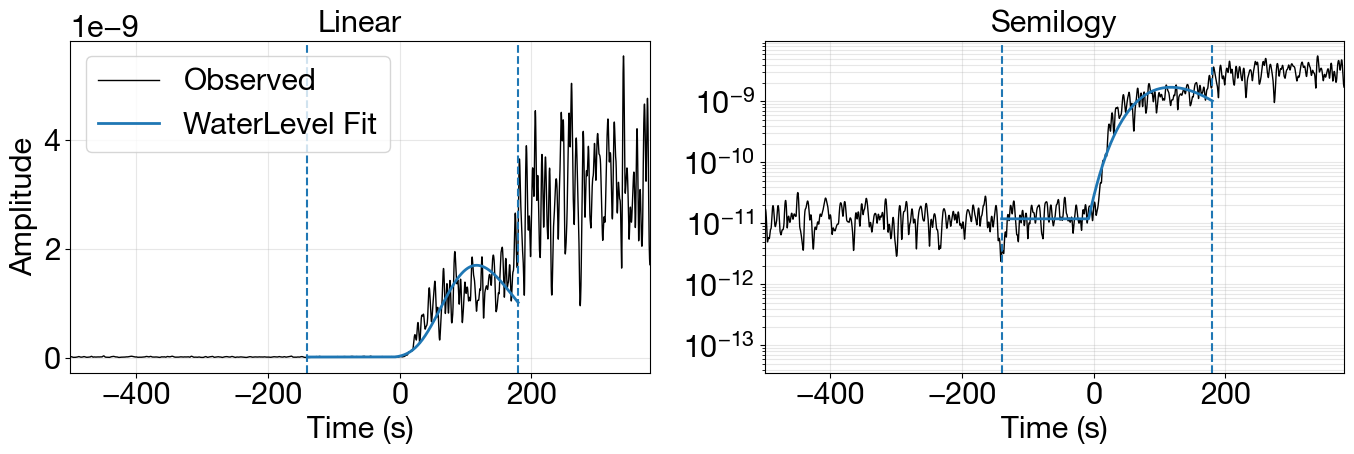

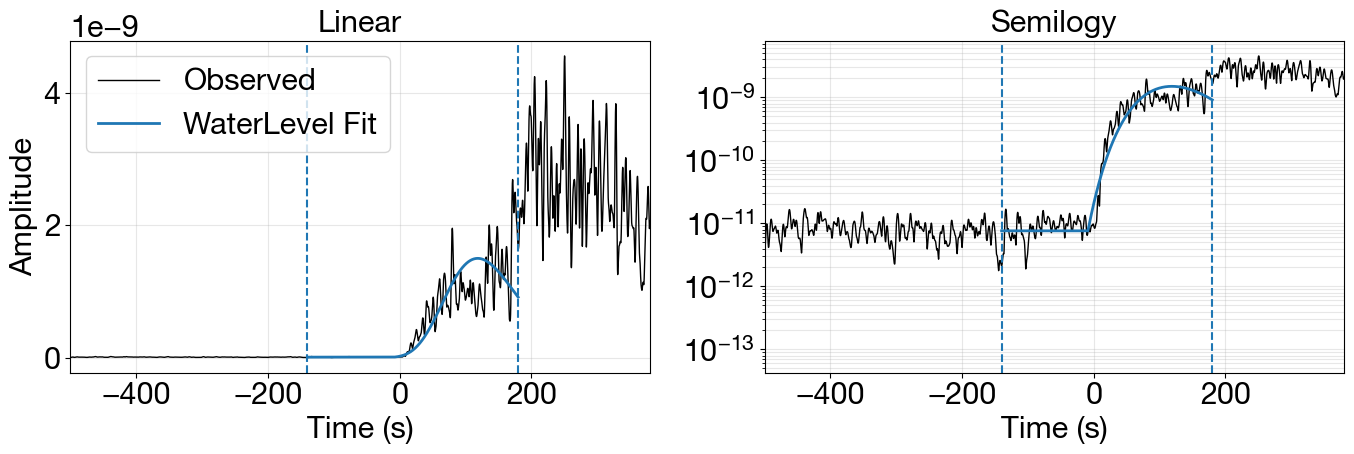

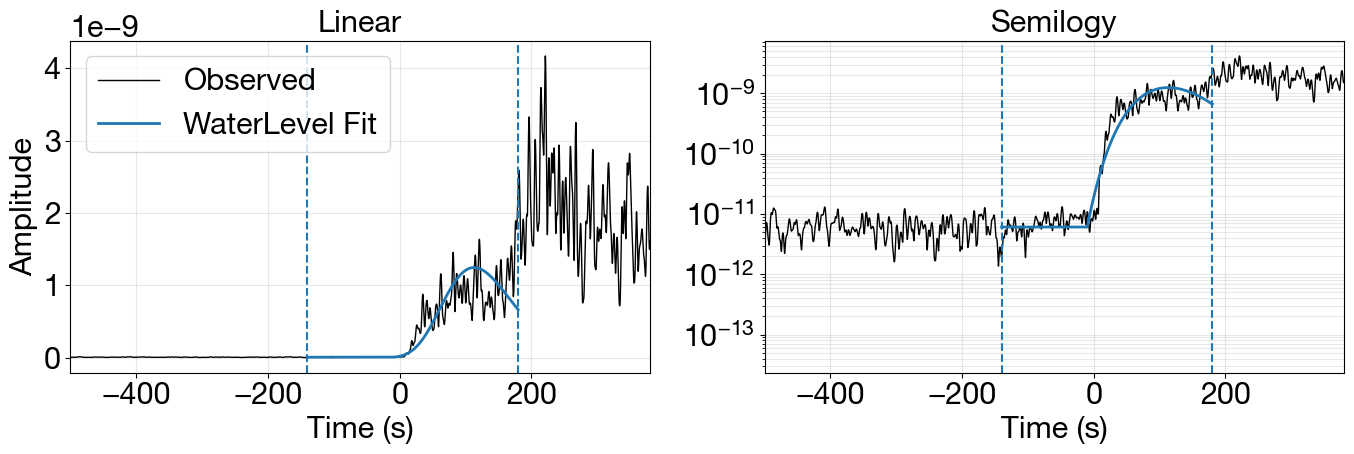

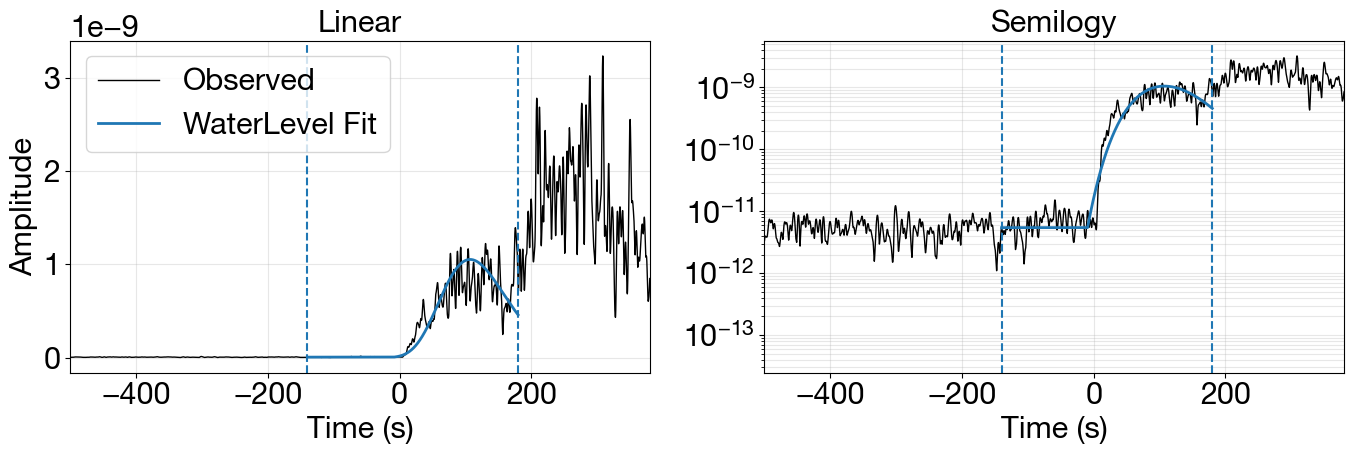

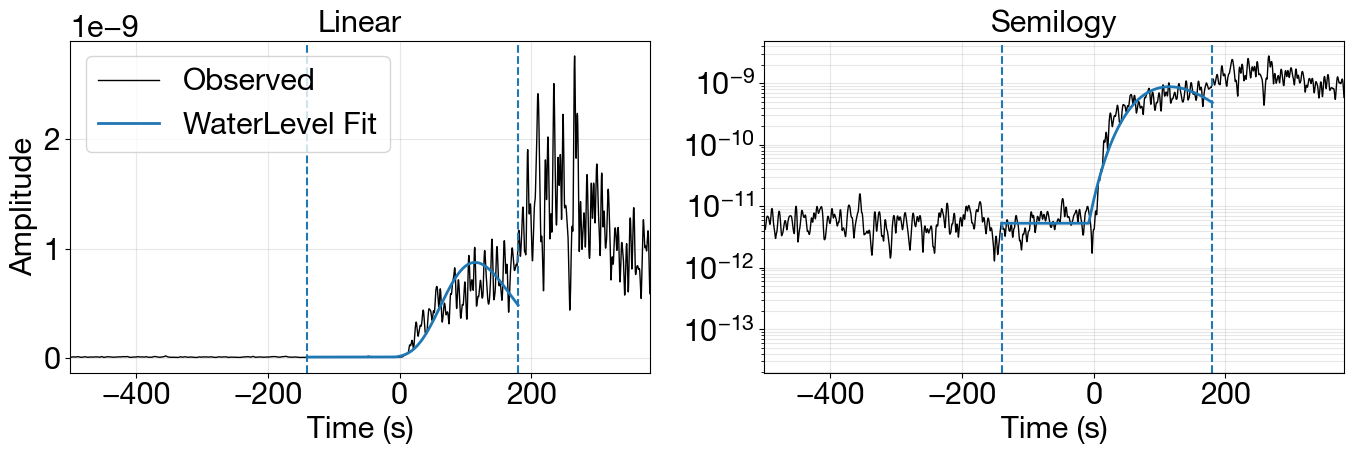

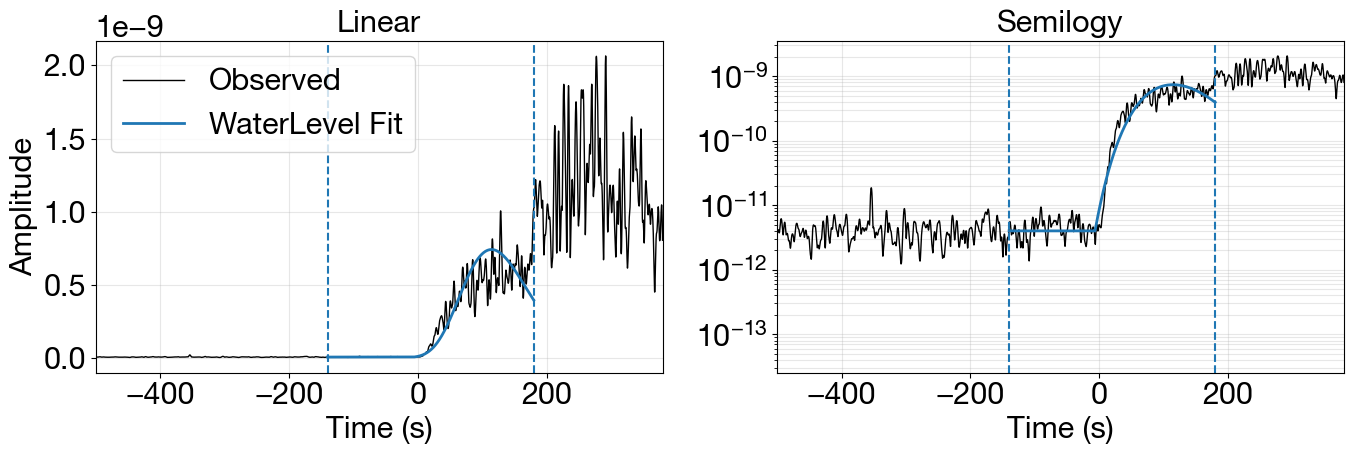

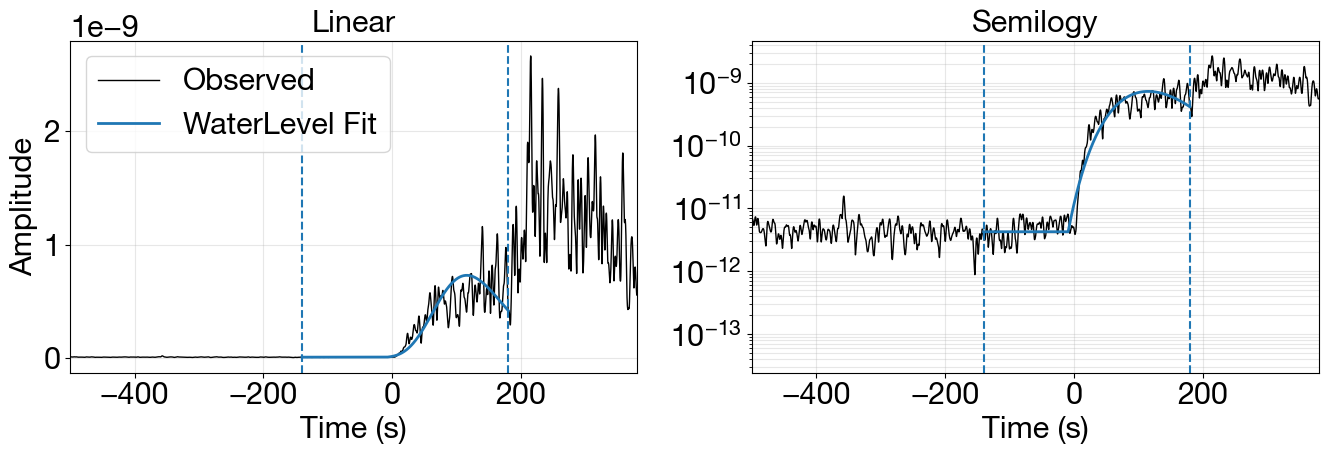

 fc_Hz  success       cost        ssr     rmse  log10_A2       q0    alpha     sigma  water_level
   3.0     True 309.799739 619.599477 0.191136  2.277442 0.769261 0.213198 68.576875 1.185378e-11
   4.0     True 343.505385 687.010770 0.201265  2.393023 0.762638 0.212318 67.916615 7.632804e-12
   5.0     True 319.090760 638.181520 0.193981  2.787543 0.738439 0.214829 66.659049 6.076609e-12
   6.0     True 327.765665 655.531330 0.196600  3.489842 0.666923 0.198678 67.526812 5.441013e-12
   7.0     True 297.660330 595.320660 0.187354  2.554153 0.743497 0.214429 66.773601 5.277453e-12
   8.0     True 219.465411 438.930823 0.160874  2.997350 0.703353 0.204620 66.675502 4.004669e-12
   9.0     True 271.272198 542.544396 0.178856  2.224933 0.780762 0.227902 65.543762 4.264540e-12


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
# -------------------------
# Your selector (as given)
# -------------------------
def select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    *,
    target_deg,
    tol_deg=0.01,
    mode="closest",
    event_col="event",
    dist_col=None
):
    d = out_df.copy()

    if dist_col is None:
        if "epi_deg" in d.columns:
            dist_col = "epi_deg"
        elif "distance_deg" in d.columns:
            dist_col = "distance_deg"
        else:
            raise KeyError("out_df must contain 'epi_deg' or 'distance_deg'")

    d[dist_col] = pd.to_numeric(d[dist_col], errors="coerce")
    d = d[d[dist_col].notna()]
    if d.empty:
        return None, None, None

    win = d[(d[dist_col] >= target_deg - tol_deg) & (d[dist_col] <= target_deg + tol_deg)]
    if win.empty:
        return None, None, None

    if mode == "closest":
        idx = (win[dist_col] - target_deg).abs().idxmin()
    elif mode == "min":
        idx = win[dist_col].idxmin()
    elif mode == "max":
        idx = win[dist_col].idxmax()
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if event_col not in win.columns:
        raise KeyError(f"out_df must contain '{event_col}' to map to event_to_trace")

    chosen_row = win.loc[idx]
    chosen_event = chosen_row[event_col]
    tr = event_to_trace.get(chosen_event)

    return tr, chosen_event, chosen_row

def log10_envelope(x):
    x = np.asarray(x, float)
    pos = x[x > 0]

    if pos.size == 0:
        floor = 1e-12
    else:
        floor = min(1e-12, max(1e-300, 0.1 * np.min(pos)))

    return np.log10(np.clip(x, floor, None))

def coda_log10_model(t, log10_A2, q0, alpha, sigma_km, D_km, water_level):

    t = np.asarray(t, float)
    t = np.clip(t, T_EPS_SEC, None)

    A2 = 10 ** log10_A2

    q = 1 - 10 ** (-q0)
    q = np.clip(q, 1e-6, 0.999999)

    sigma_km = max(1e-3, sigma_km)

    S = (D_km / sigma_km) ** 2

    inv_alpha_t = 1 / (alpha * t)

    exponent = -inv_alpha_t * S

    power_term = np.exp(alpha * t * np.log(q))

    e = A2 * power_term * inv_alpha_t * np.exp(exponent)

    e = np.clip(e, water_level, None)

    return np.log10(e)


# -------------------------
def band_edges(fc, half_bw, fs):
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp  = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms

T_EPS_SEC = 1.0

P_LOWER = np.array([-16.0, 0.01, 0.01, 0.1], float)   # log10_A2, q0, alpha, sigma
P_UPPER = np.array([15.0, 10.0, 5.0, 500.0], float)

P0 = np.array([5.0, 5.0, 1.0, 100.0], float)


def waterlevelcode(
        t,
        amp,
        *,
        D,
        fit_start,
        fit_end,
        noise_window=(0, 300),
        min_noise_n=20,
        min_fit_n=80,
        plot=True,
):

    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    finite = np.isfinite(t) & np.isfinite(amp)
    positive = amp > 0

    # -------------------------
    # compute log envelope
    # -------------------------

    env_log = log10_envelope(np.abs(amp))

    # -------------------------
    # water level
    # -------------------------

    n_lo, n_hi = noise_window

    noise_mask = finite & positive & (t >= n_lo) & (t < n_hi)

    if np.sum(noise_mask) < min_noise_n:
        raise RuntimeError("Not enough points in noise window")

    noise_log = np.mean(env_log[noise_mask])

    water_level = 10 ** noise_log

    # -------------------------
    # fit window
    # -------------------------

    fit_mask = finite & positive & (t >= fit_start) & (t <= fit_end)

    if np.sum(fit_mask) < min_fit_n:
        raise RuntimeError("Not enough points in fit window")

    t_fit = t[fit_mask] - fit_start
    y_fit = env_log[fit_mask]

    # -------------------------
    # residual function
    # -------------------------

    def residuals(p):

        y_model = coda_log10_model(
            t_fit,
            p[0],
            p[1],
            p[2],
            p[3],
            D,
            water_level
        )

        return y_model - y_fit

    # -------------------------
    # optimization
    # -------------------------

    result = least_squares(
        residuals,
        P0,
        bounds=(P_LOWER, P_UPPER),
        method="trf",
        max_nfev=2000,
    )

    if not result.success:
        raise RuntimeError("Fit did not converge")

    log10_A2, q0, alpha, sigma = result.x
    # -------------------------
    # misfit / loss diagnostics
    # -------------------------
    ssr = float(np.dot(result.fun, result.fun))     # sum of squared residuals
    cost = float(result.cost)                       # 0.5 * ssr
    rmse = float(np.sqrt(ssr / result.fun.size))    # RMSE in log10 units

    # -------------------------
    # model curve for plotting
    # -------------------------

    t_model = np.linspace(fit_start, fit_end, 2000)

    t_rel = t_model - fit_start

    y_model = coda_log10_model(
        t_rel,
        log10_A2,
        q0,
        alpha,
        sigma,
        D,
        water_level
    )

    amp_model = 10 ** y_model

    # -------------------------
    # plotting
    # -------------------------

    if plot:

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        axes[0].plot(t, amp, color="k", lw=1, label="Observed")
        axes[0].plot(t_model, amp_model, lw=2, label="WaterLevel Fit")

        axes[0].axvline(fit_start, ls="--")
        axes[0].axvline(fit_end, ls="--")

        axes[0].set_xlabel("Time (s)")
        axes[0].set_ylabel("Amplitude")
        axes[0].set_title("Linear")
        axes[0].set_xlim(-500, fit_end + 200)

        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].semilogy(t, amp, color="k", lw=1)
        axes[1].semilogy(t_model, amp_model, lw=2)

        axes[1].axvline(fit_start, ls="--")
        axes[1].axvline(fit_end, ls="--")
        axes[1].set_xlim(-500, fit_end + 200)
        axes[1].set_xlabel("Time (s)")
        axes[1].set_title("Semilogy")
        axes[1].grid(True, which="both", alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "log10_A2": log10_A2,
        "q0": q0,
        "alpha": alpha,
        "sigma": sigma,
        "water_level": water_level,
        "fit_start": fit_start,
        "fit_end": fit_end,
        "success": result.success,
        "message": result.message,
        "n_resid": int(result.fun.size),
        "ssr": ssr,
        "cost": cost,
        "rmse": rmse,
    }

# ============================================================

# ---- selection parameters
TARGET_DEG = 56     # <-- set your target epicentral distance
TOL_DEG    = 1      # <-- window around target
MODE       = "closest" # "closest" | "min" | "max"

tr_chosen, ev_chosen, row_chosen = select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    target_deg=TARGET_DEG,
    tol_deg=TOL_DEG,
    mode=MODE,
    event_col="event",
    dist_col="epi_deg",   # or None to auto-detect
)

if tr_chosen is None or ev_chosen is None:
    raise RuntimeError(f"No event found in out_df within {TARGET_DEG}±{TOL_DEG} deg (mode={MODE}).")

print("Chosen event:", ev_chosen)
print("Chosen row:\n", row_chosen)

# ---- get t0 (Excel FC-band t0) and build time axis relative to it
t0_utc = t0best_map.get(ev_chosen, pd.NaT)
if pd.isna(t0_utc):
    raise RuntimeError(f"Missing t0 for chosen event {ev_chosen} in t0best_map.")

tr_start_utc = pd.Timestamp(tr_chosen.stats.starttime.datetime, tz="UTC")
fs = float(tr_chosen.stats.sampling_rate)
x  = tr_chosen.data.astype(float)
n  = x.size
t_raw = np.arange(n) / fs  # seconds since trace start

# print(f"t0_utc={t0_utc}")
# print(f"trace_start_utc={tr_start_utc}")
# print(f"t0_offset_sec={t0_offset_sec:.3f}  (t=0 at t0_utc)")

# ---- analysis params (use yours)
FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.], float)

half_bw = 0.5
win_s   = 5
order   = 4

D_km = 1700
fit_start = -140
fit_end   = 180
noise_window = (-300, 0)

PLOT_PER_BAND = True

results_one_event = []

for fc_band in BANDS:
    # ---- band-specific t0 from matrix
    try:
        t0_utc = t0_mat.loc[ev_chosen, fc_band]
    except KeyError:
        t0_utc = pd.NaT

    if pd.isna(t0_utc):
        raise RuntimeError(f"Missing t0 for event={ev_chosen}, band={fc_band} in t0_mat.")

    # ensure UTC timestamp
    t0_utc = pd.Timestamp(t0_utc)
    if t0_utc.tzinfo is None:
        t0_utc = t0_utc.tz_localize("UTC")  # or Europe/Paris then convert, if needed
    else:
        t0_utc = t0_utc.tz_convert("UTC")

    t0_offset_sec = (t0_utc - tr_start_utc).total_seconds()
    t = t_raw - t0_offset_sec  # seconds since this band's t0

    fl, fu = band_edges(fc_band, half_bw, fs)
    env_trim, rms = env_and_rms(x, fs, fl, fu, win_s, order)

    # align time if env_trim is shorter
    if env_trim.size == t.size:
        t_env = t
        amp_for_fit = rms
    else:
        dn = t.size - env_trim.size
        i0 = dn // 2
        t_env = t[i0:i0 + env_trim.size]
        amp_for_fit = rms

    fit = waterlevelcode(
        t_env, amp_for_fit,
        D=D_km,
        fit_start=fit_start, fit_end=fit_end,
        noise_window=noise_window,
        plot=PLOT_PER_BAND,
    )

    results_one_event.append({
        "event": ev_chosen,
        "fc_Hz": float(fc_band),
        "t0_utc": t0_utc,
        "t0_offset_sec": float(t0_offset_sec),
        "fl_Hz": float(fl),
        "fu_Hz": float(fu),
        **fit
    })

# results table
res_df = pd.DataFrame(results_one_event)
print(
    res_df[["fc_Hz","success","cost","ssr","rmse","log10_A2","q0","alpha","sigma","water_level"]]
    .to_string(index=False)
)

